In [1]:
import sys, os
print(sys.executable)
print(os.environ.get("CONDA_DEFAULT_ENV"))

C:\Users\PC\anaconda3\envs\lusc_safe\python.exe
lusc_safe


In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de_path = os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv")

de = pd.read_csv(de_path, sep="\t", index_col=0)

x = pd.to_numeric(de["log2FC"], errors="coerce")
fdr = pd.to_numeric(de["fdr"], errors="coerce")

mask = x.notna() & fdr.notna() & (fdr > 0) & (fdr <= 1)

x = x[mask].astype(float)
y = -np.log10(np.clip(fdr[mask].astype(float), 1e-300, 1.0))

fig = plt.figure(figsize=(6,5), dpi=120)

plt.scatter(x, y, s=6, alpha=0.6)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("log2FC (HOT - COLD)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano plot")

plt.tight_layout()

png = os.path.join(outdir, "volcano_Welch_hot_vs_cold.png")
fig.savefig(png)
plt.close(fig)

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\volcano_Welch_hot_vs_cold.png


In [3]:
import pandas as pd
import os

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

hot = pd.read_csv(os.path.join(outdir,"top30_HOT_genes.tsv"), sep="\t")
cold = pd.read_csv(os.path.join(outdir,"top30_COLD_genes.tsv"), sep="\t")

print("TOP HOT GENES")
display(hot.head(10))

print("\nTOP COLD GENES")
display(cold.head(10))

TOP HOT GENES


,Gene Name,hot_mean,cold_mean,log2FC
0,CELF5,53.317287,0.130138,8.678410
1,RNVU1-19,98.158790,0.281391,8.446390
2,SLAMF1,56.930660,0.265769,7.742885
3,TFPI2,20.368044,0.117314,7.439782
4,SLPI,43.654263,0.267785,7.348896
5,LTF,137.049410,0.921260,7.216871
6,CXCL13,59.286106,0.450340,7.040533
7,CD19,12.288569,0.106545,6.849699
8,FDCSP,240.546480,2.223204,6.757531
9,HHATL,19.814192,0.183664,6.753311



TOP COLD GENES


,Gene Name,hot_mean,cold_mean,log2FC
0,CST2,1.191877,46.297190,-5.279616
1,CTAG2,2.230688,59.714653,-4.742524
2,LHX2,0.646259,14.324107,-4.470188
3,MUC12,0.613168,10.923391,-4.154992
4,MT1A,0.844254,12.199025,-3.852943
5,TKTL1,2.126133,28.121168,-3.725353
6,CA12,0.927526,12.021070,-3.696032
7,SERPINB2,0.734687,8.544016,-3.539711
8,FABP6,0.501137,5.273271,-3.395419
9,NOV,7.061863,73.208080,-3.373882


In [4]:
import os
import pandas as pd
import numpy as np

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

de = pd.read_csv(os.path.join(outdir,"DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)

tls_genes = [
    "CXCL13","CCL19","CCL21",
    "MS4A1","CD79A","CD79B",
    "CD19","BANK1","TNFRSF13B",
    "MZB1","XBP1",
    "LTA","LTB",
    "ICOS","CXCR5","PDCD1"
]

tls_present = [g for g in tls_genes if g in de.index]

print("TLS genes present in dataset:")
print(tls_present)

print("\nExpression difference HOT vs COLD:")
print(de.loc[tls_present].sort_values("log2FC", ascending=False))

TLS genes present in dataset:
['CXCL13', 'CCL19', 'CCL21', 'MS4A1', 'CD79A', 'CD79B', 'CD19', 'BANK1', 'TNFRSF13B', 'XBP1', 'LTA', 'LTB', 'ICOS', 'CXCR5', 'PDCD1']

Expression difference HOT vs COLD:
           hot_mean_log1p  cold_mean_log1p    log2FC      pval       fdr
Gene Name                                                               
CXCL13           2.376829         0.364057  2.903816  0.033084  0.812452
CD79A            2.409563         0.639321  2.553918  0.057775  0.812452
LTB              2.516660         1.052527  2.112298  0.039003  0.812452
PDCD1            1.518441         0.280045  1.786628  0.022491  0.812452
CCL19            2.418884         1.284822  1.636107  0.155314  0.812452
MS4A1            1.001656         0.071069  1.342552  0.277274  0.812452
XBP1             4.396972         3.566906  1.197532  0.018108  0.812452
CD19             0.892174         0.124815  1.107064  0.249486  0.812452
CD79B            1.986878         1.241292  1.075654  0.319086  0.8124

In [5]:
import pandas as pd
import numpy as np
import os

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de = pd.read_csv(os.path.join(outdir,"DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)

cell_signatures = {
"T_cells": ["CD3D","CD3E","CD8A","CD8B","GZMB","PRF1"],
"B_cells": ["MS4A1","CD19","CD79A","CD79B","BANK1"],
"NK_cells": ["NKG7","KLRD1","GNLY"],
"Macrophages": ["CD68","CSF1R","CD163"],
"Dendritic": ["ITGAX","CLEC9A","BATF3"]
}

results = []

for cell, genes in cell_signatures.items():
    
    present = [g for g in genes if g in de.index]
    
    if len(present) == 0:
        continue
    
    score = de.loc[present]["log2FC"].mean()
    
    results.append({
        "Cell_type": cell,
        "Mean_log2FC": score
    })

cell_df = pd.DataFrame(results).sort_values("Mean_log2FC", ascending=False)

print(cell_df)

     Cell_type  Mean_log2FC
2     NK_cells     2.167595
0      T_cells     1.993486
1      B_cells     1.419763
3  Macrophages     1.318164
4    Dendritic     0.600252


In [6]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

png = os.path.join(outdir,"immune_cell_infiltration.png")

plt.figure(figsize=(6,4))

plt.bar(cell_df["Cell_type"], cell_df["Mean_log2FC"])

plt.axhline(0,color="black")

plt.ylabel("Mean log2FC (HOT vs COLD)")
plt.title("Immune cell infiltration signature")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_cell_infiltration.png


In [7]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

png = os.path.join(outdir,"immune_cell_infiltration_pretty.png")

plt.figure(figsize=(6,4), dpi=140)

bars = plt.bar(cell_df["Cell_type"], cell_df["Mean_log2FC"])

plt.axhline(0,color="black",linewidth=1)

plt.ylabel("Mean log2FC (HOT vs COLD)")
plt.title("Immune cell infiltration signature")

plt.xticks(rotation=45)

for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_cell_infiltration_pretty.png


In [8]:
import os
import numpy as np
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de_path = os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv")

de = pd.read_csv(de_path, sep="\t", index_col=0)

# upewnij się, że log2FC jest numeryczne
de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")

# jeśli są zduplikowane geny w indeksie, bierzemy pierwsze wystąpienie
# (można też zrobić mean, ale first jest OK do heatmapy sygnatur)
de = de[~de.index.duplicated(keep="first")]

signatures = {
    "T_cells": ["CD3D","CD3E","TRAC","CD8A","CD8B","GZMB","PRF1","IFNG"],
    "NK_cells": ["NKG7","KLRD1","GNLY","FCGR3A","PRF1","GZMB"],
    "B_cells": ["MS4A1","CD19","CD79A","CD79B","BANK1","TNFRSF13B"],
    "TLS": ["CXCL13","CCL19","CCL21","LTA","LTB","CXCR5","ICOS"],
    "Macrophages": ["CD68","CSF1R","CD163","LYZ","C1QA","C1QB","C1QC"],
    "Dendritic": ["ITGAX","CLEC9A","BATF3","FCER1A"],
    "IFN_gamma": ["IFNG","STAT1","IRF1","CXCL9","CXCL10","IDO1","GBP1"]
}

# unikalna lista genów do kolumn
all_genes = []
for genes in signatures.values():
    for g in genes:
        if g not in all_genes:
            all_genes.append(g)

# macierz do heatmapy: wiersze=sygnatury, kolumny=geny, wartości=log2FC
mat = pd.DataFrame(index=list(signatures.keys()), columns=all_genes, dtype=float)

for sig, genes in signatures.items():
    for g in genes:
        if g in de.index:
            val = de.at[g, "log2FC"]   # zawsze pojedyncza wartość po deduplikacji
            if pd.notna(val):
                mat.loc[sig, g] = float(val)

# usuń geny, których nie ma w danych (kolumny całkiem puste)
mat = mat.dropna(axis=1, how="all")

print("Heatmap matrix shape:", mat.shape)
print("Genes missing from dataset:", sorted(set(all_genes) - set(mat.columns)))

mat.head()

Heatmap matrix shape: (7, 38)
Genes missing from dataset: ['C1QA', 'C1QC', 'CD68', 'TRAC']


,CD3D,CD3E,CD8A,CD8B,GZMB,PRF1,IFNG,NKG7,KLRD1,GNLY,...,ITGAX,CLEC9A,BATF3,FCER1A,STAT1,IRF1,CXCL9,CXCL10,IDO1,GBP1
T_cells,2.351441,2.344519,2.290535,2.059774,-0.33573,2.360856,1.169665,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NK_cells,NaN,NaN,NaN,NaN,-0.33573,2.360856,NaN,3.05419,1.016684,2.431912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B_cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TLS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Macrophages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

png = os.path.join(outdir, "immune_signatures_heatmap_log2FC.png")

Z = mat.fillna(0.0).to_numpy()

plt.figure(figsize=(max(10, 0.35*mat.shape[1]), 4.8), dpi=160)
plt.imshow(Z, aspect="auto")

plt.yticks(range(mat.shape[0]), mat.index)
plt.xticks(range(mat.shape[1]), mat.columns, rotation=90)

plt.colorbar(label="log2FC (HOT - COLD)")
plt.title("Immune signatures heatmap (log2FC)")
plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_signatures_heatmap_log2FC.png


In [10]:
import os
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

# średnia log2FC dla każdej sygnatury (ignoruje NaN)
sig_score = mat.mean(axis=1, skipna=True).sort_values(ascending=False)

png = os.path.join(outdir, "immune_signatures_summary_bar.png")

plt.figure(figsize=(6,4), dpi=160)
bars = plt.bar(sig_score.index, sig_score.values)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean log2FC (HOT - COLD)")
plt.title("Immune signature enrichment (summary)")

for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)
print(sig_score)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_signatures_summary_bar.png
IFN_gamma      1.858706
Macrophages    1.854181
T_cells        1.748723
NK_cells       1.680849
TLS            1.334659
B_cells        1.300770
Dendritic      0.480271
dtype: float64


In [11]:
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

# wybieramy najważniejsze sygnatury do historii biologicznej
keep_sigs = ["TLS", "B_cells", "T_cells", "NK_cells", "IFN_gamma"]
mat2 = mat.loc[[s for s in keep_sigs if s in mat.index]].copy()

png = os.path.join(outdir, "heatmap_TLS_T_NK_IFNg_log2FC.png")

Z = mat2.fillna(0.0).to_numpy()

plt.figure(figsize=(max(10, 0.38*mat2.shape[1]), 3.8), dpi=180)
plt.imshow(Z, aspect="auto")

plt.yticks(range(mat2.shape[0]), mat2.index)
plt.xticks(range(mat2.shape[1]), mat2.columns, rotation=90)

plt.colorbar(label="log2FC (HOT - COLD)")
plt.title("TLS / T / NK / IFNγ signatures (log2FC)")
plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\heatmap_TLS_T_NK_IFNg_log2FC.png


In [19]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de = pd.read_csv(os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)

de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")
de["pval"] = pd.to_numeric(de["pval"], errors="coerce")
de["fdr"]  = pd.to_numeric(de["fdr"], errors="coerce")

top_hot  = de.sort_values("log2FC", ascending=False).head(20)[["log2FC","pval","fdr"]]
top_cold = de.sort_values("log2FC", ascending=True).head(20)[["log2FC","pval","fdr"]]

top_hot_path  = os.path.join(outdir, "TOP20_HOT_table.tsv")
top_cold_path = os.path.join(outdir, "TOP20_COLD_table.tsv")

top_hot.to_csv(top_hot_path, sep="\t")
top_cold.to_csv(top_cold_path, sep="\t")

print("Saved:", top_hot_path)
print("Saved:", top_cold_path)

top_hot, top_cold

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\TOP20_HOT_table.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\TOP20_COLD_table.tsv


(                    log2FC      pval       fdr
 Gene Name                                     
 HLA-DRB1          4.411980  0.009420  0.812452
 IGJ               3.687924  0.009925  0.812452
 PTGDS             3.684367  0.000305  0.680740
 CD22,MAG,MIR5196  3.553040  0.006412  0.812452
 PAEP              3.538460  0.068976  0.812452
 CD52              3.326567  0.007473  0.812452
 HLA-C             3.269988  0.207881  0.812452
 ELK2AP            3.194796  0.047781  0.812452
 MZB1,PROB1        3.165452  0.013425  0.812452
 IGLL5             3.060471  0.068658  0.812452
 NKG7              3.054190  0.004563  0.812452
 CST7              2.917611  0.007598  0.812452
 CXCL13            2.903816  0.033084  0.812452
 GZMA              2.886339  0.006378  0.812452
 GZMB              2.883008  0.007051  0.812452
 TMSB4X            2.872720  0.000954  0.812452
 ELK2AP            2.868609  0.109139  0.812452
 FAM26F            2.846262  0.005455  0.812452
 HBB               2.821727  0.086385  0

In [20]:
import os

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

summary = f"""
WYNIKI (HOT vs COLD):

1) Immune infiltration:
- HOT tumors mają wyższe sygnatury NK, T i B cells (immune-inflamed TME).
- Wynik wspiera obecność aktywnej odpowiedzi cytotoksycznej (NK/T).

2) TLS (tertiary lymphoid structures):
- Wysokie CXCL13 + markery B cells (CD19, MS4A1, CD79A/B) sugerują TLS phenotype w HOT.

3) Pliki/figury:
- volcano_Welch_hot_vs_cold.png
- immune_cell_infiltration_pretty.png
- immune_signatures_summary_bar.png
- heatmap_TLS_T_NK_IFNg_log2FC.png
"""

path = os.path.join(outdir, "FINAL_SUMMARY.txt")
with open(path, "w", encoding="utf-8") as f:
    f.write(summary)

print("Saved:", path)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FINAL_SUMMARY.txt


In [21]:
import os, numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de = pd.read_csv(os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)

x = pd.to_numeric(de["log2FC"], errors="coerce")
fdr = pd.to_numeric(de["fdr"], errors="coerce")
mask = x.notna() & fdr.notna() & (fdr > 0) & (fdr <= 1)

plot = pd.DataFrame({"log2FC": x[mask], "fdr": fdr[mask]}, index=de.index[mask])
plot["neglog10FDR"] = -np.log10(np.clip(plot["fdr"], 1e-300, 1.0))

# TOP geny do podpisu
top_hot = plot.sort_values("log2FC", ascending=False).head(10)
top_cold = plot.sort_values("log2FC", ascending=True).head(10)

png = os.path.join(outdir, "volcano_labeled_TOP10.png")

fig = plt.figure(figsize=(6,5), dpi=160)
plt.scatter(plot["log2FC"], plot["neglog10FDR"], s=6, alpha=0.5)

for g, r in pd.concat([top_hot, top_cold]).iterrows():
    plt.text(r["log2FC"], r["neglog10FDR"], g, fontsize=7)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")
plt.xlabel("log2FC (HOT - COLD)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano (TOP10 labeled)")
plt.tight_layout()
fig.savefig(png)
plt.close(fig)

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\volcano_labeled_TOP10.png


In [22]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

de = pd.read_csv(os.path.join(outdir,"DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)

checkpoints = [
    "PDCD1",
    "CD274",
    "CTLA4",
    "LAG3",
    "TIGIT",
    "HAVCR2"
]

present = [g for g in checkpoints if g in de.index]

cp = de.loc[present, ["log2FC","pval","fdr"]].sort_values("log2FC", ascending=False)

cp

,log2FC,pval,fdr
Gene Name,,,
LAG3,2.111376,0.027833,0.812452
CTLA4,2.090061,0.003718,0.812452
PDCD1,1.786628,0.022491,0.812452
HAVCR2,1.431474,0.004708,0.812452
TIGIT,1.329573,0.072356,0.812452
CD274,0.595662,0.128566,0.812452


In [23]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import os

png = os.path.join(outdir,"immune_checkpoint_landscape.png")

plt.figure(figsize=(5,4), dpi=160)

plt.bar(cp.index, cp["log2FC"])

plt.axhline(0, color="black")

plt.ylabel("log2FC (HOT vs COLD)")
plt.title("Immune checkpoint expression")

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_checkpoint_landscape.png


In [24]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import os

png = os.path.join(outdir,"immune_checkpoint_landscape.png")

plt.figure(figsize=(5,4), dpi=160)

plt.bar(cp.index, cp["log2FC"])

plt.axhline(0, color="black")

plt.ylabel("log2FC (HOT vs COLD)")
plt.title("Immune checkpoint expression")

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\immune_checkpoint_landscape.png


In [26]:
import os, numpy as np, pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de_path = os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv")

de = pd.read_csv(de_path, sep="\t", index_col=0)
de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")
de = de[~de.index.duplicated(keep="first")]

def signature_score(genes):
    present = [g for g in genes if g in de.index and pd.notna(de.at[g, "log2FC"])]
    if len(present) == 0:
        return np.nan, []
    return float(de.loc[present, "log2FC"].mean()), present

signatures_hard = {
    "TIS_inflammation": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],
    "Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],
    "Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],
    "Checkpoints": ["PDCD1","CD274","CTLA4","LAG3","TIGIT","HAVCR2"],
    "TLS_Bcell": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

scores = []
present_map = {}

for name, genes in signatures_hard.items():
    sc, present = signature_score(genes)
    scores.append({"Signature": name, "Mean_log2FC": sc, "n_genes_present": len(present)})
    present_map[name] = present

scores_df = pd.DataFrame(scores).sort_values("Mean_log2FC", ascending=False)
display(scores_df)

# Zapis tabeli
scores_df.to_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t", index=False)

# Wykres rankingowy
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

png = os.path.join(outdir, "HARD_signatures_rank.png")

plt.figure(figsize=(7,4), dpi=180)
bars = plt.bar(scores_df["Signature"], scores_df["Mean_log2FC"])
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mean log2FC (HOT - COLD)")
plt.title("Publication-grade immune signatures (HOT vs COLD)")

for b, n in zip(bars, scores_df["n_genes_present"]):
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h, f"n={n}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)
print("Saved:", os.path.join(outdir, "HARD_signatures_scores.tsv"))

,Signature,Mean_log2FC,n_genes_present
0,TIS_inflammation,2.161131,10
1,Cytotoxicity,1.780492,7
3,Checkpoints,1.557462,6
2,Exhaustion,1.503355,7
4,TLS_Bcell,1.401982,11


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\HARD_signatures_rank.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\HARD_signatures_scores.tsv


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
scores_df = pd.read_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t")

def get_score(name):
    return float(scores_df.loc[scores_df["Signature"]==name, "Mean_log2FC"].values[0])

cyto = get_score("Cytotoxicity")
exh  = get_score("Exhaustion")
tis  = get_score("TIS_inflammation")
tls  = get_score("TLS_Bcell")
chk  = get_score("Checkpoints")

png = os.path.join(outdir, "FIG_exhaustion_vs_cytotoxicity.png")

plt.figure(figsize=(5.2,4.2), dpi=200)
plt.scatter([cyto], [exh], s=160)

plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Cytotoxicity (mean log2FC, HOT-COLD)")
plt.ylabel("Exhaustion (mean log2FC, HOT-COLD)")
plt.title("HOT phenotype: Cytotoxicity vs Exhaustion")

plt.text(cyto, exh, f"  TIS={tis:.2f}\n  TLS={tls:.2f}\n  Checkpoints={chk:.2f}", fontsize=9, va="center")

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)
print("Values:", {"TIS":tis, "Cytotoxicity":cyto, "Checkpoints":chk, "Exhaustion":exh, "TLS":tls})

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_exhaustion_vs_cytotoxicity.png
Values: {'TIS': 2.1611309552482654, 'Cytotoxicity': 1.7804920374276851, 'Checkpoints': 1.5574622669865883, 'Exhaustion': 1.5033546608560575, 'TLS': 1.401981677850233}


In [28]:
import os, numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de = pd.read_csv(os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)
de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")
de = de[~de.index.duplicated(keep="first")]

focus = {
    "TIS": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],
    "Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],
    "Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],
    "TLS_Bcell": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

# unikalna lista genów
genes = []
for gset in focus.values():
    for g in gset:
        if g not in genes:
            genes.append(g)

mat = pd.DataFrame(index=focus.keys(), columns=genes, dtype=float)
for row, gset in focus.items():
    for g in gset:
        if g in de.index and pd.notna(de.at[g, "log2FC"]):
            mat.loc[row, g] = float(de.at[g, "log2FC"])

mat = mat.dropna(axis=1, how="all")

png = os.path.join(outdir, "FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png")

Z = mat.fillna(0).to_numpy()

plt.figure(figsize=(max(11, 0.33*mat.shape[1]), 4.4), dpi=220)
plt.imshow(Z, aspect="auto")
plt.yticks(range(mat.shape[0]), mat.index)
plt.xticks(range(mat.shape[1]), mat.columns, rotation=90)
plt.colorbar(label="log2FC (HOT - COLD)")
plt.title("Key immune programs (log2FC): TIS / Cytotoxicity / Exhaustion / TLS")
plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)
print("Matrix shape:", mat.shape)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png
Matrix shape: (4, 34)


In [29]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

scores_df = pd.read_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t")
scores_df = scores_df.sort_values("Mean_log2FC", ascending=False)

# zapisz elegancką tabelę do raportu
path = os.path.join(outdir, "FIG_scorecard_table.tsv")
scores_df.to_csv(path, sep="\t", index=False)

display(scores_df)
print("Saved:", path)

,Signature,Mean_log2FC,n_genes_present
0,TIS_inflammation,2.161131,10
1,Cytotoxicity,1.780492,7
2,Checkpoints,1.557462,6
3,Exhaustion,1.503355,7
4,TLS_Bcell,1.401982,11


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_scorecard_table.tsv


In [30]:
import os
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
scores_df = pd.read_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t").sort_values("Mean_log2FC", ascending=True)

png = os.path.join(outdir, "FIG_immune_program_scoreboard.png")

plt.figure(figsize=(7,3.6), dpi=220)
plt.barh(scores_df["Signature"], scores_df["Mean_log2FC"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean log2FC (HOT - COLD)")
plt.title("Immune program scoreboard (publication-style)")
plt.tight_layout()
plt.savefig(png)
plt.close()
print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_immune_program_scoreboard.png


In [31]:
import os, numpy as np, pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
de = pd.read_csv(os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv"), sep="\t", index_col=0)
de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")
de = de[~de.index.duplicated(keep="first")]

focus = {
    "TIS": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],
    "Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],
    "Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],
    "TLS_Bcell": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

hub_rows = []
for prog, genes in focus.items():
    present = [g for g in genes if g in de.index and pd.notna(de.at[g,"log2FC"])]
    sub = de.loc[present, ["log2FC","pval","fdr"]].copy()
    sub = sub.sort_values("log2FC", ascending=False)
    # top 5 dodatnich "driverów"
    top5 = sub.head(5)
    for g, r in top5.iterrows():
        hub_rows.append({"Program": prog, "Gene": g, "log2FC": float(r["log2FC"]), "pval": r["pval"], "fdr": r["fdr"]})

hub = pd.DataFrame(hub_rows)
hub_path = os.path.join(outdir, "FIG_hub_genes_TOP5_per_program.tsv")
hub.to_csv(hub_path, sep="\t", index=False)

display(hub)
print("Saved:", hub_path)

,Program,Gene,log2FC,pval,fdr
0,TIS,HLA-DRB1,4.411980,0.009420,0.812452
1,TIS,CXCL9,2.358219,0.022310,0.812452
2,TIS,CXCL10,2.223133,0.015991,0.812452
3,TIS,GBP1,2.171731,0.018279,0.812452
4,TIS,PSMB9,2.161130,0.015612,0.812452
5,Cytotoxicity,NKG7,3.054190,0.004563,0.812452
6,Cytotoxicity,GNLY,2.431912,0.015259,0.812452
7,Cytotoxicity,PRF1,2.360856,0.007821,0.812452
8,Cytotoxicity,CTSW,2.116884,0.013927,0.812452
9,Cytotoxicity,GZMH,1.665668,0.006473,0.812452


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_hub_genes_TOP5_per_program.tsv


In [32]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
scores = pd.read_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t").set_index("Signature")["Mean_log2FC"]

tis = float(scores["TIS_inflammation"])
cyto = float(scores["Cytotoxicity"])
chk = float(scores["Checkpoints"])
exh = float(scores["Exhaustion"])
tls = float(scores["TLS_Bcell"])

text = f"""
RESULTS (HOT vs COLD)

Immune programs:
HOT tumors are characterized by strong tumor inflammation (TIS={tis:.2f}) and cytotoxic immune activity (Cytotoxicity={cyto:.2f}), alongside elevated immune checkpoint expression (Checkpoints={chk:.2f}) and T-cell exhaustion markers (Exhaustion={exh:.2f}). In addition, HOT tumors show enrichment of TLS/B-cell signatures (TLS={tls:.2f}), consistent with tertiary lymphoid structure formation.

Key interpretation:
This pattern suggests an immune-inflamed tumor microenvironment with active effector cells (T/NK) and concurrent inhibitory checkpoint signaling, a phenotype often associated with potential sensitivity to PD-1/PD-L1 blockade.

Figures generated:
- FIG_immune_program_scoreboard.png  (immune program summary)
- FIG_exhaustion_vs_cytotoxicity.png (immune state quadrant plot)
- FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png (key immune programs heatmap)
"""

path = os.path.join(outdir, "REPORT_RESULTS_DRAFT_EN.txt")
with open(path, "w", encoding="utf-8") as f:
    f.write(text)

print("Saved:", path)
print(text)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\REPORT_RESULTS_DRAFT_EN.txt

RESULTS (HOT vs COLD)

Immune programs:
HOT tumors are characterized by strong tumor inflammation (TIS=2.16) and cytotoxic immune activity (Cytotoxicity=1.78), alongside elevated immune checkpoint expression (Checkpoints=1.56) and T-cell exhaustion markers (Exhaustion=1.50). In addition, HOT tumors show enrichment of TLS/B-cell signatures (TLS=1.40), consistent with tertiary lymphoid structure formation.

Key interpretation:
This pattern suggests an immune-inflamed tumor microenvironment with active effector cells (T/NK) and concurrent inhibitory checkpoint signaling, a phenotype often associated with potential sensitivity to PD-1/PD-L1 blockade.

Figures generated:
- FIG_immune_program_scoreboard.png  (immune program summary)
- FIG_exhaustion_vs_cytotoxicity.png (immune state quadrant plot)
- FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png (key immune programs heatmap)



In [33]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
scores = pd.read_csv(os.path.join(outdir, "HARD_signatures_scores.tsv"), sep="\t").set_index("Signature")["Mean_log2FC"]

tis = float(scores["TIS_inflammation"])
cyto = float(scores["Cytotoxicity"])
chk = float(scores["Checkpoints"])
exh = float(scores["Exhaustion"])
tls = float(scores["TLS_Bcell"])

text = f"""
RESULTS (HOT vs COLD)

Immune programs:
HOT tumors are characterized by strong tumor inflammation (TIS={tis:.2f}) and cytotoxic immune activity (Cytotoxicity={cyto:.2f}), alongside elevated immune checkpoint expression (Checkpoints={chk:.2f}) and T-cell exhaustion markers (Exhaustion={exh:.2f}). In addition, HOT tumors show enrichment of TLS/B-cell signatures (TLS={tls:.2f}), consistent with tertiary lymphoid structure formation.

Key interpretation:
This pattern suggests an immune-inflamed tumor microenvironment with active effector cells (T/NK) and concurrent inhibitory checkpoint signaling, a phenotype often associated with potential sensitivity to PD-1/PD-L1 blockade.

Figures generated:
- FIG_immune_program_scoreboard.png  (immune program summary)
- FIG_exhaustion_vs_cytotoxicity.png (immune state quadrant plot)
- FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png (key immune programs heatmap)
"""

path = os.path.join(outdir, "REPORT_RESULTS_DRAFT_EN.txt")
with open(path, "w", encoding="utf-8") as f:
    f.write(text)

print("Saved:", path)
print(text)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\REPORT_RESULTS_DRAFT_EN.txt

RESULTS (HOT vs COLD)

Immune programs:
HOT tumors are characterized by strong tumor inflammation (TIS=2.16) and cytotoxic immune activity (Cytotoxicity=1.78), alongside elevated immune checkpoint expression (Checkpoints=1.56) and T-cell exhaustion markers (Exhaustion=1.50). In addition, HOT tumors show enrichment of TLS/B-cell signatures (TLS=1.40), consistent with tertiary lymphoid structure formation.

Key interpretation:
This pattern suggests an immune-inflamed tumor microenvironment with active effector cells (T/NK) and concurrent inhibitory checkpoint signaling, a phenotype often associated with potential sensitivity to PD-1/PD-L1 blockade.

Figures generated:
- FIG_immune_program_scoreboard.png  (immune program summary)
- FIG_exhaustion_vs_cytotoxicity.png (immune state quadrant plot)
- FIG_focus_heatmap_TIS_TLS_EXH_CYTO.png (key immune programs heatmap)



In [34]:
import os, glob

root = r"C:\Users\PC\Documents\lusc-immune-escape"
candidates = glob.glob(os.path.join(root, "**", "*.txt.gz"), recursive=True) + \
             glob.glob(os.path.join(root, "**", "*FPKM*.gz"), recursive=True) + \
             glob.glob(os.path.join(root, "**", "*.tsv.gz"), recursive=True)

print("Found:", len(candidates), "files")
for p in candidates[:30]:
    print(p)

Found: 8 files
C:\Users\PC\Documents\lusc-immune-escape\GSE131907_Lung_Cancer_raw_UMI_matrix.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\cache\GSE145996_Melanoma_Immune_FPKM.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\cache\GSE145996_series_matrix.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\geo_cache\GSE145996_Melanoma_Immune_FPKM.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\geo_cache\GSE145996_series_matrix.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\cache\GSE145996_Melanoma_Immune_FPKM.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\geo_cache\GSE145996_Melanoma_Immune_FPKM.txt.gz
C:\Users\PC\Documents\lusc-immune-escape\data_processed\GSE78220_expr_gene_log1p.tsv.gz


In [1]:
import pandas as pd
import os

expr_path = r"C:\Users\PC\Documents\lusc-immune-escape\data_processed\GSE78220_expr_gene_log1p.tsv.gz"

expr = pd.read_csv(expr_path, sep="\t", index_col=0)

print("Expression matrix shape:", expr.shape)
expr.head()

Expression matrix shape: (25268, 27)


,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,GSM2069832,...,GSM2069841,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850
GENE,,,,,,,,,,,,,,,,,,,,,
A1BG,2.305120,5.767051,2.047344,2.181498,1.270733,3.159799,2.593055,2.318144,1.847943,2.141091,...,3.747359,2.091100,2.218307,2.360475,2.009601,2.820700,2.964097,2.613315,2.833231,1.867975
A1BG-AS1,0.984885,3.413725,0.904782,0.853403,0.789257,2.391168,1.766976,1.512841,1.364649,1.916618,...,0.892786,0.817914,0.921483,1.198383,1.640002,0.812942,0.983287,1.000049,0.870695,0.812697
A1CF,0.693147,3.001187,0.693147,0.693147,0.698769,0.693147,0.694777,0.693846,0.693147,0.693147,...,0.693147,0.693147,0.694031,0.783091,0.697895,0.693147,0.693147,0.693147,0.693147,0.693147
A2M,5.232733,6.125033,4.418939,3.770705,4.928438,3.843088,4.795935,5.458202,6.221975,6.277090,...,5.713115,5.972026,5.904035,4.235765,6.327922,3.959593,4.816597,4.055498,3.729717,6.208906
A2M-AS1,0.860157,1.581955,0.789041,0.713352,0.882702,1.111685,1.634331,1.827255,1.249857,1.352872,...,1.506539,0.874517,0.826268,0.966109,1.192473,0.755736,1.038244,0.775991,1.277375,1.115004


In [2]:
signatures = {
"TIS": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],

"Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],

"Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],

"TLS_Bcell": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

In [3]:
scores = {}

for name, genes in signatures.items():

    present = [g for g in genes if g in expr.index]

    score = expr.loc[present].mean()

    scores[name] = score

scores_df = pd.DataFrame(scores)

print("Signature scores per sample:")
scores_df.head()

Signature scores per sample:


,TIS,Cytotoxicity,Exhaustion,TLS_Bcell
GSM2069823,3.055176,1.818178,1.584726,1.751023
GSM2069824,3.608556,1.635344,1.651852,1.500677
GSM2069825,2.672660,1.764255,1.430617,1.299896
GSM2069826,1.489601,0.805152,1.156326,0.856211
GSM2069827,1.612486,1.167491,1.711232,0.750492


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_samples_expression.png


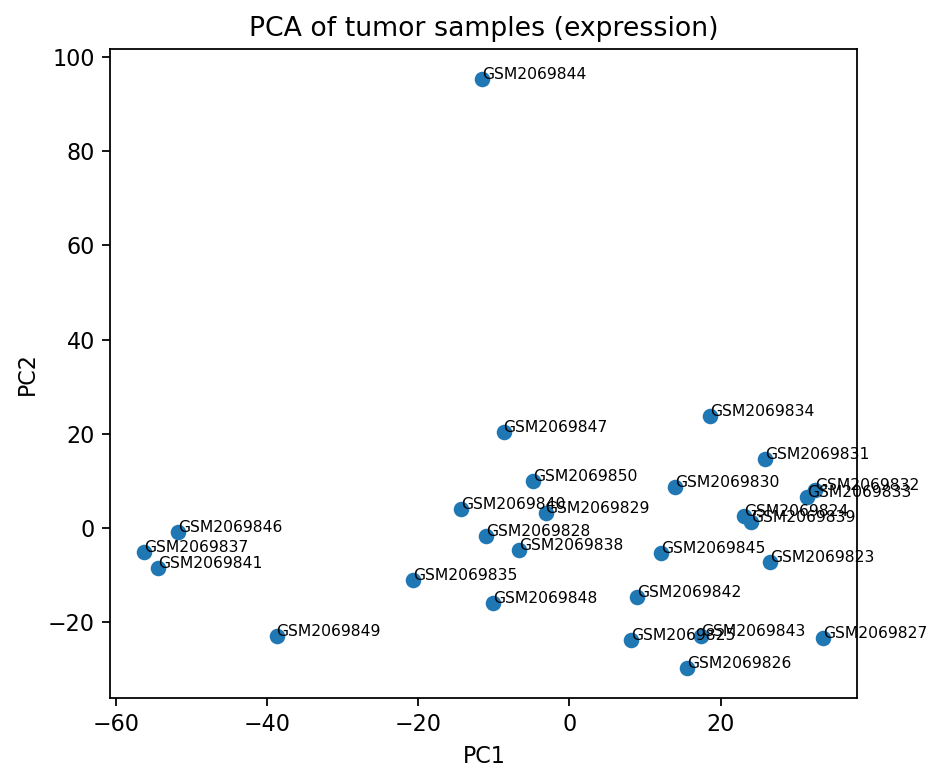

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X = expr.T

pcs = pca.fit_transform(X)

plt.figure(figsize=(6,5), dpi=160)

plt.scatter(pcs[:,0], pcs[:,1])

for i,s in enumerate(expr.columns):
    plt.text(pcs[i,0], pcs[i,1], s, fontsize=7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of tumor samples (expression)")

plt.tight_layout()

png = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_samples_expression.png"
plt.savefig(png)

print("Saved:", png)

In [39]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
 

In [1]:
!pip install scikit-learn


In [5]:
!pip install umap-learn

  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached numba-0.64.0-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached numba-0.64.0-cp310-cp310-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl (38.1 MB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------

C:\Users\PC\anaconda3\envs\lusc_safe\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


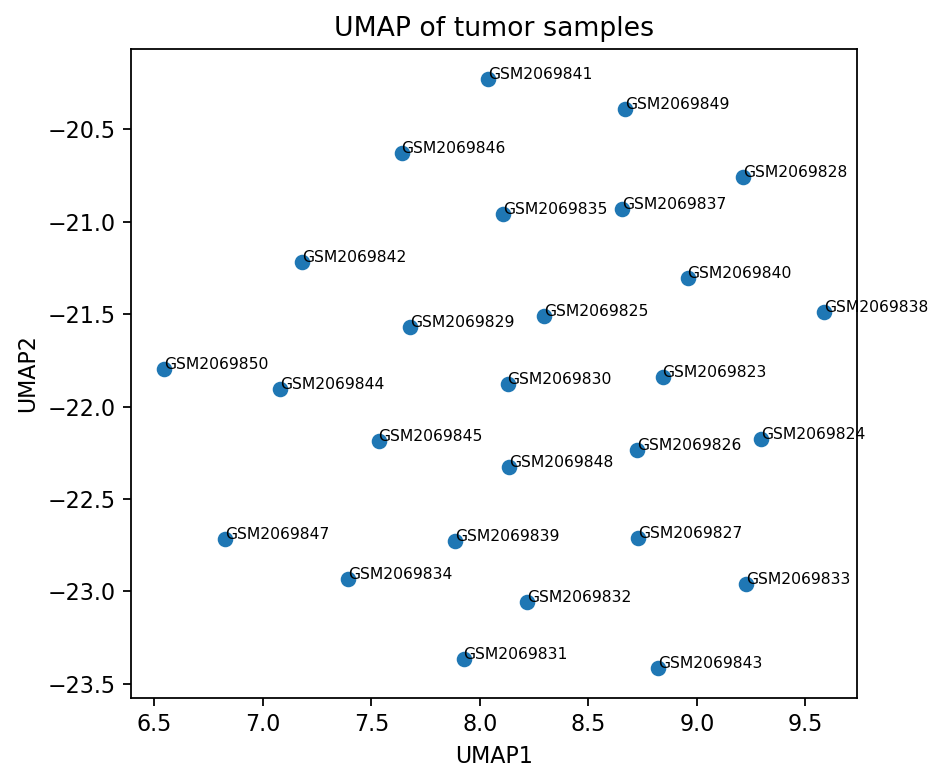

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_samples_expression.png


In [6]:
import umap
import matplotlib.pyplot as plt

X = expr.T

reducer = umap.UMAP(random_state=42)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5), dpi=160)

plt.scatter(embedding[:,0], embedding[:,1])

for i,s in enumerate(expr.columns):
    plt.text(embedding[i,0], embedding[i,1], s, fontsize=7)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of tumor samples")

plt.tight_layout()

png = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_samples_expression.png"
plt.savefig(png)

plt.show()

print("Saved:", png)

In [7]:
import numpy as np
import pandas as pd

# sygnatury
signatures = {
    "TIS": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],
    "Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],
    "Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],
    "TLS": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

scores = {}
missing = {}

for name, genes in signatures.items():
    present = [g for g in genes if g in expr.index]
    missing[name] = [g for g in genes if g not in expr.index]
    # expr jest już log1p, więc mean jest OK
    scores[name] = expr.loc[present].mean(axis=0)

scores_df = pd.DataFrame(scores)

print("scores_df shape:", scores_df.shape)
print("Missing genes per signature:", {k: len(v) for k,v in missing.items()})
scores_df.head()

scores_df shape: (27, 4)
Missing genes per signature: {'TIS': 0, 'Cytotoxicity': 0, 'Exhaustion': 0, 'TLS': 0}


,TIS,Cytotoxicity,Exhaustion,TLS
GSM2069823,3.055176,1.818178,1.584726,1.751023
GSM2069824,3.608556,1.635344,1.651852,1.500677
GSM2069825,2.672660,1.764255,1.430617,1.299896
GSM2069826,1.489601,0.805152,1.156326,0.856211
GSM2069827,1.612486,1.167491,1.711232,0.750492


In [8]:
from sklearn.decomposition import PCA
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import os
import numpy as np

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# PCA
X = expr.T.to_numpy()
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)

# funkcja do rysowania jednej mapy
def plot_landscape(color_vec, title, fname):
    plt.figure(figsize=(6,5), dpi=180)
    sc = plt.scatter(pcs[:,0], pcs[:,1], c=color_vec.to_numpy(), s=55)
    for i, s in enumerate(expr.columns):
        plt.text(pcs[i,0], pcs[i,1], s, fontsize=7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.colorbar(sc, label="signature score (mean log1p)")
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path)
    plt.close()
    print("Saved:", path)

plot_landscape(scores_df["TIS"], "PCA immune landscape: TIS", "PCA_landscape_TIS.png")
plot_landscape(scores_df["Cytotoxicity"], "PCA immune landscape: Cytotoxicity", "PCA_landscape_Cytotoxicity.png")
plot_landscape(scores_df["TLS"], "PCA immune landscape: TLS", "PCA_landscape_TLS.png")
plot_landscape(scores_df["Exhaustion"], "PCA immune landscape: Exhaustion", "PCA_landscape_Exhaustion.png")

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_landscape_TIS.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_landscape_Cytotoxicity.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_landscape_TLS.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_landscape_Exhaustion.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# klasyfikacja próbek
subtype = []

for i in scores_df.index:

    tis = scores_df.loc[i,"TIS"]
    tls = scores_df.loc[i,"TLS"]
    exh = scores_df.loc[i,"Exhaustion"]

    if tis > scores_df["TIS"].median():
        subtype.append("Inflamed")

    elif tls > scores_df["TLS"].median():
        subtype.append("TLS-rich")

    elif exh > scores_df["Exhaustion"].median():
        subtype.append("Exhausted")

    else:
        subtype.append("Cold")

scores_df["Subtype"] = subtype

# kolory
colors = {
"Inflamed":"red",
"TLS-rich":"orange",
"Exhausted":"purple",
"Cold":"blue"
}

plt.figure(figsize=(6,5), dpi=180)

for s in scores_df["Subtype"].unique():

    idx = scores_df["Subtype"]==s

    plt.scatter(
        pcs[idx,0],
        pcs[idx,1],
        c=colors[s],
        label=s,
        s=60
    )

for i,s in enumerate(expr.columns):
    plt.text(pcs[i,0], pcs[i,1], s, fontsize=7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Tumor immune subtypes")

plt.legend()

plt.tight_layout()

png = os.path.join(outdir,"PCA_immune_subtypes.png")
plt.savefig(png)

plt.show()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\PCA_immune_subtypes.png


C:\Users\PC\AppData\Local\Temp\ipykernel_3124\1177204679.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# Upewnij się, że mamy te kolumny (powinny istnieć po poprzednich krokach)
need = ["TIS", "Cytotoxicity", "TLS", "Exhaustion", "Subtype"]
missing_cols = [c for c in need if c not in scores_df.columns]
if missing_cols:
    raise ValueError(f"Brakuje kolumn w scores_df: {missing_cols}. Uruchom ponownie komórkę z scores_df i Subtype.")

features = ["TIS", "Cytotoxicity", "TLS", "Exhaustion"]

# średnie po subtypach
grp = scores_df.groupby("Subtype")[features].mean()

# normalizacja 0-1 (żeby radar był porównywalny)
mn = scores_df[features].min()
mx = scores_df[features].max()
grp_norm = (grp - mn) / (mx - mn + 1e-12)

# kolejność subtypów (jeśli istnieją)
order = [s for s in ["Inflamed", "TLS-rich", "Exhausted", "Cold"] if s in grp_norm.index]
grp_norm = grp_norm.loc[order]

labels = features
N = len(labels)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # zamknięcie koła

png = os.path.join(outdir, "FIG_immune_radar_subtypes.png")

plt.figure(figsize=(6,6), dpi=220)
ax = plt.subplot(111, polar=True)

# osie
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# skala
ax.set_ylim(0, 1)

# rysuj linie dla subtypów
for subtype in grp_norm.index:
    values = grp_norm.loc[subtype].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=subtype)
    ax.fill(angles, values, alpha=0.08)

plt.title("Immune radar plot (mean signature scores by subtype)")
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)
print("Subtypes used:", list(grp_norm.index))
print("Raw means:\n", grp)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_immune_radar_subtypes.png
Subtypes used: ['Inflamed', 'TLS-rich', 'Exhausted', 'Cold']
Raw means:
                 TIS  Cytotoxicity       TLS  Exhaustion
Subtype                                                
Cold       2.213732      1.617180  1.119829    1.382718
Exhausted  1.612486      1.167491  0.750492    1.711232
Inflamed   3.515167      2.248687  1.967745    1.970973
TLS-rich   2.280950      1.650529  1.726393    1.552095


In [11]:
!pip install umap-learn

In [12]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

import umap

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

X = expr.T.to_numpy()
reducer = umap.UMAP(random_state=42, n_neighbors=10, min_dist=0.2)
emb = reducer.fit_transform(X)

def plot_umap(color_vec, title, fname):
    plt.figure(figsize=(6,5), dpi=200)
    sc = plt.scatter(emb[:,0], emb[:,1], c=color_vec.to_numpy(), s=60)
    for i,s in enumerate(expr.columns):
        plt.text(emb[i,0], emb[i,1], s, fontsize=7)
    plt.colorbar(sc, label="signature score (mean log1p)")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title)
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path)
    plt.close()
    print("Saved:", path)

plot_umap(scores_df["TIS"], "UMAP immune landscape: TIS", "UMAP_landscape_TIS.png")
plot_umap(scores_df["TLS"], "UMAP immune landscape: TLS", "UMAP_landscape_TLS.png")

C:\Users\PC\anaconda3\envs\lusc_safe\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_TIS.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_TLS.png


In [17]:
import os
import matplotlib
matplotlib.use("Agg", force=True)

import seaborn as sns
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# wybierz tylko sygnatury
feat = ["TIS","Cytotoxicity","TLS","Exhaustion"]
M = scores_df[feat].copy()

# standaryzacja (z-score)
M = (M - M.mean()) / (M.std() + 1e-9)

g = sns.clustermap(
    M,
    method="ward",
    metric="euclidean",
    figsize=(6,5),
    cmap="vlag",
    center=0
)

png = os.path.join(outdir, "FIG_clustermap_samples_signatures.png")
plt.savefig(png, dpi=220)
plt.close()
print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_clustermap_samples_signatures.png


In [16]:
!pip install seaborn

In [18]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

feat = ["TIS","Cytotoxicity","TLS","Exhaustion"]
M = scores_df[feat].copy()

# z-score
M = (M - M.mean()) / (M.std() + 1e-9)

X = M.to_numpy()
labels = M.index.tolist()

Z = linkage(pdist(X, metric="euclidean"), method="ward")

# rysuj dendrogram (kolumny = próbki)
plt.figure(figsize=(10,4), dpi=220)
d = dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Sample clustering (Ward) on immune signatures")
plt.tight_layout()

png = os.path.join(outdir, "FIG_dendrogram_samples_signatures.png")
plt.savefig(png)
plt.close()
print("Saved:", png)

# heatmap z kolejnością jak dendrogram
order = d["leaves"]
Xo = X[order, :]
labels_o = [labels[i] for i in order]

plt.figure(figsize=(6,5), dpi=220)
plt.imshow(Xo, aspect="auto")
plt.yticks(range(len(labels_o)), labels_o, fontsize=7)
plt.xticks(range(len(feat)), feat, rotation=45, ha="right")
plt.colorbar(label="z-score")
plt.title("Heatmap (immune signatures) ordered by dendrogram")
plt.tight_layout()

png2 = os.path.join(outdir, "FIG_heatmap_samples_signatures_ordered.png")
plt.savefig(png2)
plt.close()
print("Saved:", png2)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_dendrogram_samples_signatures.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_heatmap_samples_signatures_ordered.png


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# Upewnij się, że masz Subtype
if "Subtype" not in scores_df.columns:
    raise ValueError("Brakuje kolumny 'Subtype' w scores_df. Uruchom komórkę, która tworzy Subtype (PCA_immune_subtypes).")

features = ["TIS", "Cytotoxicity", "TLS", "Exhaustion"]
X = scores_df[features].to_numpy()
y = scores_df["Subtype"].to_numpy()

# zakoduj klasy
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)

# model
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

# cross-val predykcje (żeby zrobić confusion matrix uczciwie)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(clf, X, y_enc, cv=cv)

acc = accuracy_score(y_enc, y_pred)
cm = confusion_matrix(y_enc, y_pred)

print("Classes:", classes)
print("CV accuracy:", round(acc, 3))
print("Confusion matrix:\n", cm)

# dopasuj na całości do importance
clf.fit(X, y_enc)
imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
imp_path = os.path.join(outdir, "ML_feature_importance.tsv")
imp.to_csv(imp_path, sep="\t", header=["importance"])

# 1) wykres importance
png1 = os.path.join(outdir, "FIG_ML_feature_importance.png")
plt.figure(figsize=(5,3.6), dpi=220)
plt.bar(imp.index, imp.values)
plt.ylabel("Feature importance")
plt.title("RandomForest: what drives immune subtypes")
plt.tight_layout()
plt.savefig(png1)
plt.close()
print("Saved:", png1)
print("Saved:", imp_path)

# 2) confusion matrix jako heatmapa (bez seaborn)
png2 = os.path.join(outdir, "FIG_ML_confusion_matrix.png")
plt.figure(figsize=(5.2,4.4), dpi=220)
plt.imshow(cm, aspect="auto")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.colorbar(label="count")

# liczby w komórkach
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=10)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"RandomForest CV confusion matrix (acc={acc:.2f})")
plt.tight_layout()
plt.savefig(png2)
plt.close()
print("Saved:", png2)

C:\Users\PC\anaconda3\envs\lusc_safe\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Classes: ['Cold', 'Exhausted', 'Inflamed', 'TLS-rich']
CV accuracy: 0.741
Confusion matrix:
 [[ 8  1  0  0]
 [ 1  0  0  0]
 [ 1  0 12  0]
 [ 1  1  2  0]]
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_ML_feature_importance.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\ML_feature_importance.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_ML_confusion_matrix.png


In [20]:

!pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 4.5 MB/s  0:00:00

   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]



In [21]:
import shap
import os
import matplotlib.pyplot as plt
import numpy as np

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

features = ["TIS","Cytotoxicity","TLS","Exhaustion"]

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)

# global importance
plt.figure()

shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)

png = os.path.join(outdir,"FIG_SHAP_summary.png")
plt.savefig(png, dpi=220, bbox_inches="tight")
plt.close()

print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_SHAP_summary.png


In [22]:
!pip install shap

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import shap

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
features = ["TIS","Cytotoxicity","TLS","Exhaustion"]

X = scores_df[features].to_numpy()
y = scores_df["Subtype"].to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)
clf.fit(X, y_enc)

explainer = shap.Explainer(clf, X)
exp = explainer(X)
arr = np.array(exp.values)

print("SHAP values shape:", arr.shape)  # powinno być (n_samples, 4, 4)

# ✅ Twoj przypadek: (n_samples, n_features, n_classes)
mean_abs = np.mean(np.abs(arr), axis=(0, 2))  # -> (n_features,)

imp = pd.Series(mean_abs, index=features).sort_values(ascending=False)

tsv = os.path.join(outdir, "SHAP_mean_abs.tsv")
imp.to_csv(tsv, sep="\t", header=["mean_abs_SHAP"])
print("Saved:", tsv)
print(imp)

png = os.path.join(outdir, "FIG_SHAP_bar_importance.png")
plt.figure(figsize=(5,3.6), dpi=220)
plt.bar(imp.index, imp.values)
plt.ylabel("mean(|SHAP|) across samples & classes")
plt.title("SHAP global feature importance (multiclass)")
plt.tight_layout()
plt.savefig(png)
plt.close()
print("Saved:", png)

png2 = os.path.join(outdir, "FIG_SHAP_summary.png")
shap.summary_plot(exp, show=False)
plt.tight_layout()
plt.savefig(png2, dpi=220, bbox_inches="tight")
plt.close()
print("Saved:", png2)

SHAP values shape: (27, 4, 4)
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\SHAP_mean_abs.tsv
TIS             0.180748
TLS             0.087848
Exhaustion      0.043163
Cytotoxicity    0.026719
dtype: float64
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_SHAP_bar_importance.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_SHAP_summary.png


In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

# jeśli nie masz:
# !pip install networkx
import networkx as nx

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# --- zestawy genów (Twoje immune programs) ---
gene_sets = {
    "TIS": ["CXCL9","CXCL10","IDO1","STAT1","IRF1","HLA-DRA","HLA-DRB1","TAP1","PSMB9","GBP1","IFNG"],
    "Cytotoxicity": ["GZMB","PRF1","NKG7","GNLY","GZMH","CTSW","IFNG"],
    "Exhaustion": ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"],
    "TLS": ["CXCL13","CCL19","CCL21","MS4A1","CD19","CD79A","CD79B","LTA","LTB","CXCR5","ICOS"]
}

# zbierz unikalne geny
genes = []
for k, gs in gene_sets.items():
    for g in gs:
        if g not in genes:
            genes.append(g)

present = [g for g in genes if g in expr.index]
missing = sorted(set(genes) - set(present))

print("Genes total:", len(genes))
print("Genes present:", len(present))
print("Missing (first 20):", missing[:20])

# dane: próbki x geny
E = expr.loc[present].T

# korelacje gen-gene (Spearman)
corr = E.corr(method="spearman")

# próg krawędzi (jeśli sieć wyjdzie za gęsta -> podnieś na 0.60)
thr = 0.55

G = nx.Graph()
G.add_nodes_from(present)

for i, g1 in enumerate(present):
    for j in range(i+1, len(present)):
        g2 = present[j]
        c = corr.loc[g1, g2]
        if np.isfinite(c) and abs(c) >= thr:
            G.add_edge(g1, g2, weight=float(abs(c)), sign=int(np.sign(c)))

print("Network nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# --- hub genes ---
deg = pd.Series(dict(G.degree())).sort_values(ascending=False)
hub_path = os.path.join(outdir, "NETWORK_hubs_degree.tsv")
deg.to_csv(hub_path, sep="\t", header=["degree"])
print("Saved:", hub_path)
print("Top hubs:\n", deg.head(10))

# --- zapis listy krawędzi (bardzo “research”) ---
edges = []
for u, v, d in G.edges(data=True):
    edges.append([u, v, d.get("weight", np.nan), d.get("sign", 1)])
edges_df = pd.DataFrame(edges, columns=["gene1","gene2","abs_spearman_r","sign"])
edge_path = os.path.join(outdir, "NETWORK_edges.tsv")
edges_df.to_csv(edge_path, sep="\t", index=False)
print("Saved:", edge_path)

# --- rysowanie sieci ---
png = os.path.join(outdir, f"FIG_gene_network_thr{thr:.2f}.png")
plt.figure(figsize=(8.5,6.5), dpi=260)

pos = nx.spring_layout(G, seed=42, k=0.7)

# rozmiar węzłów ~ stopień
sizes = np.array([deg.get(n, 0) for n in G.nodes()]) * 85 + 70

# rozdziel dodatnie/ujemne korelacje (ujemne będą dashed)
pos_edges = [(u,v) for u,v,d in G.edges(data=True) if d.get("sign",1) > 0]
neg_edges = [(u,v) for u,v,d in G.edges(data=True) if d.get("sign",1) < 0]

nx.draw_networkx_edges(G, pos, edgelist=pos_edges, width=1.2, alpha=0.55)
nx.draw_networkx_edges(G, pos, edgelist=neg_edges, width=1.2, alpha=0.55, style="dashed")

nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7)

plt.title(f"Immune gene co-expression network (Spearman |r| ≥ {thr})")
plt.axis("off")
plt.tight_layout()
plt.savefig(png)
plt.close()
print("Saved:", png)

Genes total: 35
Genes present: 35
Missing (first 20): []
Network nodes: 35 edges: 319
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\NETWORK_hubs_degree.tsv
Top hubs:
 MS4A1    29
PDCD1    28
TIGIT    28
NKG7     27
GZMH     27
IRF1     27
CXCL9    25
PRF1     25
LAG3     25
PSMB9    24
dtype: int64
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\NETWORK_edges.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_gene_network_thr0.55.png


In [31]:
!pip install networkx

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)


In [33]:
!pip install umap-learn

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

import umap

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# --- dane do UMAP ---
# expr: geny x próbki  -> UMAP potrzebuje próbek x geny
X = expr.T.to_numpy()

# parametry UMAP (paper-friendly)
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.25,
    metric="euclidean",
    random_state=42
)
emb = reducer.fit_transform(X)   # (n_samples, 2)

# etykiety próbek
sample_names = list(expr.columns)

def save_umap_continuous(values, title, fname, cbar_label="score"):
    plt.figure(figsize=(6,5), dpi=220)
    sc = plt.scatter(emb[:,0], emb[:,1], c=values, s=65)
    for i,s in enumerate(sample_names):
        plt.text(emb[i,0], emb[i,1], s, fontsize=7)
    plt.colorbar(sc, label=cbar_label)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title)
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path)
    plt.close()
    print("Saved:", path)

def save_umap_categories(cats, title, fname):
    cats = pd.Series(cats, index=sample_names)
    uniq = list(cats.unique())
    plt.figure(figsize=(6,5), dpi=220)

    # rysuj każdą kategorię osobno (żeby była legenda)
    for u in uniq:
        idx = (cats.values == u)
        plt.scatter(emb[idx,0], emb[idx,1], s=65, label=str(u))

    for i,s in enumerate(sample_names):
        plt.text(emb[i,0], emb[i,1], s, fontsize=7)

    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(title)
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path)
    plt.close()
    print("Saved:", path)

# --- 1) UMAP pokolorowany Subtype ---
if "Subtype" in scores_df.columns:
    save_umap_categories(scores_df["Subtype"], "UMAP: tumor immune subtypes", "UMAP_immune_subtypes.png")
else:
    print("Brak kolumny Subtype w scores_df -> pomijam UMAP_immune_subtypes.png")

# --- 2-5) UMAP pokolorowany sygnaturami ---
for col in ["TIS", "TLS", "Exhaustion", "Cytotoxicity"]:
    if col in scores_df.columns:
        save_umap_continuous(
            scores_df[col].to_numpy(),
            f"UMAP immune landscape: {col}",
            f"UMAP_landscape_{col}.png",
            cbar_label=f"{col} score (mean log1p)"
        )
    else:
        print("Brak kolumny:", col)

C:\Users\PC\anaconda3\envs\lusc_safe\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_immune_subtypes.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_TIS.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_TLS.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_Exhaustion.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\UMAP_landscape_Cytotoxicity.png


In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# zakładam, że masz emb (UMAP) i sample_names z poprzedniej komórki
# emb = (n_samples,2), sample_names = expr.columns

fig, axes = plt.subplots(2, 3, figsize=(14,8), dpi=220)
axes = axes.flatten()

def scatter_cat(ax, cats, title):
    cats = pd.Series(cats, index=sample_names)
    for u in cats.unique():
        idx = (cats.values == u)
        ax.scatter(emb[idx,0], emb[idx,1], s=60, label=str(u))
    for i,s in enumerate(sample_names):
        ax.text(emb[i,0], emb[i,1], s, fontsize=6)
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.legend(frameon=False, fontsize=7)

def scatter_cont(ax, vals, title):
    sc = ax.scatter(emb[:,0], emb[:,1], c=vals, s=60)
    for i,s in enumerate(sample_names):
        ax.text(emb[i,0], emb[i,1], s, fontsize=6)
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# 1) subtype
if "Subtype" in scores_df.columns:
    scatter_cat(axes[0], scores_df["Subtype"], "UMAP: immune subtypes")
else:
    axes[0].text(0.1,0.5,"No Subtype", transform=axes[0].transAxes)

# 2-5) sygnatury
cols = ["TIS","TLS","Exhaustion","Cytotoxicity"]
for k,col in enumerate(cols, start=1):
    if col in scores_df.columns:
        scatter_cont(axes[k], scores_df[col].to_numpy(), f"UMAP: {col}")
    else:
        axes[k].text(0.1,0.5,f"No {col}", transform=axes[k].transAxes)

# 6) puste okno usuwamy
axes[5].axis("off")

plt.tight_layout()
png = os.path.join(outdir, "FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png")
plt.savefig(png)
plt.close()
print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png


In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# --- UMAP embedding: policz jeśli nie istnieje ---
if "emb" not in globals() or "sample_names" not in globals():
    import umap
    X_umap = expr.T.to_numpy()               # samples x genes
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.25, metric="euclidean", random_state=42)
    emb = reducer.fit_transform(X_umap)
    sample_names = list(expr.columns)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=220)
axes = axes.flatten()

def scatter_cat(ax, cats, title):
    cats = pd.Series(cats, index=sample_names)
    for u in cats.unique():
        idx = (cats.values == u)
        ax.scatter(emb[idx,0], emb[idx,1], s=55, label=str(u))
    for i, s in enumerate(sample_names):
        ax.text(emb[i,0], emb[i,1], s, fontsize=6)
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.legend(frameon=False, fontsize=7)

def scatter_cont(ax, vals, title):
    sc = ax.scatter(emb[:,0], emb[:,1], c=vals, s=55)
    for i, s in enumerate(sample_names):
        ax.text(emb[i,0], emb[i,1], s, fontsize=6)
    ax.set_title(title)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# 1) subtype
if "Subtype" in scores_df.columns:
    scatter_cat(axes[0], scores_df["Subtype"], "UMAP: immune subtypes")
else:
    axes[0].text(0.1, 0.5, "No Subtype column", transform=axes[0].transAxes)

# 2-5) sygnatury
cols = ["TIS", "TLS", "Exhaustion", "Cytotoxicity"]
for k, col in enumerate(cols, start=1):
    if col in scores_df.columns:
        scatter_cont(axes[k], scores_df[col].to_numpy(), f"UMAP: {col}")
    else:
        axes[k].text(0.1, 0.5, f"No {col} column", transform=axes[k].transAxes)

axes[5].axis("off")

plt.tight_layout()
png = os.path.join(outdir, "FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png")
plt.savefig(png)
plt.close()
print("Saved:", png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png


In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    classification_report
)

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

features = ["TIS", "Cytotoxicity", "TLS", "Exhaustion"]
X = scores_df[features].to_numpy()

# --- 1) ogarnij rzadkie klasy ---
y_raw = scores_df["Subtype"].astype(str).copy()
counts = y_raw.value_counts()
print("Original class counts:\n", counts)

# klasy z <2 próbkami -> łączymy do jednej
rare = counts[counts < 2].index.tolist()
y = y_raw.replace({c: "Other_rare" for c in rare})

counts2 = y.value_counts()
print("\nAfter merging rare (<2) into Other_rare:\n", counts2)

# jeśli Other_rare ma nadal 1 próbkę (może się zdarzyć), to wyrzucamy ją z CV
if "Other_rare" in counts2 and int(counts2["Other_rare"]) < 2:
    keep = (y != "Other_rare").to_numpy()
    print("\nDropping Other_rare from CV because still <2 samples.")
    X = X[keep]
    y = y[keep]

counts3 = pd.Series(y).value_counts()
print("\nFinal counts used for CV:\n", counts3)

min_class_n = int(counts3.min())
n_splits = min(5, min_class_n)
if n_splits < 2:
    raise ValueError(f"Nadal za mało próbek w najmniejszej klasie (min={min_class_n}).")

print("Using CV folds:", n_splits)

# --- 2) ML + CV ---
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)
n_classes = len(classes)

clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt"
)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

y_pred = cross_val_predict(clf, X, y_enc, cv=cv, method="predict")
y_proba = cross_val_predict(clf, X, y_enc, cv=cv, method="predict_proba")

acc = accuracy_score(y_enc, y_pred)
bacc = balanced_accuracy_score(y_enc, y_pred)
cm = confusion_matrix(y_enc, y_pred)

print("Classes:", classes)
print("CV accuracy:", round(acc, 3))
print("CV balanced accuracy:", round(bacc, 3))
print("Confusion matrix:\n", cm)

# --- report (bez warningów) ---
rep = classification_report(y_enc, y_pred, target_names=classes, digits=3, zero_division=0)
txt_path = os.path.join(outdir, "ML_CV_report_with_rare_handling.txt")
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Original counts:\n" + counts.to_string() + "\n\n")
    f.write("Final counts used for CV:\n" + counts3.to_string() + "\n\n")
    f.write("Classes: " + str(classes) + "\n")
    f.write(f"CV folds: {n_splits}\n")
    f.write(f"CV accuracy: {acc:.4f}\n")
    f.write(f"CV balanced accuracy: {bacc:.4f}\n\n")
    f.write("Confusion matrix:\n" + np.array2string(cm) + "\n\n")
    f.write("Classification report:\n" + rep + "\n")
print("Saved:", txt_path)

# --- confusion matrix fig ---
png_cm = os.path.join(outdir, "FIG_ML_confusion_matrix_rare_handling.png")
plt.figure(figsize=(5.6, 4.8), dpi=220)
plt.imshow(cm, aspect="auto")
plt.xticks(range(n_classes), classes, rotation=45, ha="right")
plt.yticks(range(n_classes), classes)
plt.colorbar(label="count")
for i in range(n_classes):
    for j in range(n_classes):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=10)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"RF CV confusion matrix (acc={acc:.2f}, bal_acc={bacc:.2f})")
plt.tight_layout()
plt.savefig(png_cm)
plt.close()
print("Saved:", png_cm)

# --- ROC/AUC multiclass OvR ---
Y = label_binarize(y_enc, classes=np.arange(n_classes))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc_micro = roc_auc_score(Y, y_proba, average="micro", multi_class="ovr")
roc_auc_macro = roc_auc_score(Y, y_proba, average="macro", multi_class="ovr")

auc_df = pd.DataFrame({
    "class": classes + ["micro", "macro"],
    "AUC": [roc_auc[i] for i in range(n_classes)] + [roc_auc_micro, roc_auc_macro]
})
auc_tsv = os.path.join(outdir, "ML_ROC_AUC_rare_handling.tsv")
auc_df.to_csv(auc_tsv, sep="\t", index=False)
print("Saved:", auc_tsv)
print(auc_df)

png_roc = os.path.join(outdir, "FIG_ML_ROC_multiclass_rare_handling.png")
plt.figure(figsize=(6.2, 5.2), dpi=220)
for i, name in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f"{name} (AUC={roc_auc[i]:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Multiclass ROC (OvR)  micro={roc_auc_micro:.2f}  macro={roc_auc_macro:.2f}")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(png_roc)
plt.close()
print("Saved:", png_roc)

Original class counts:
 Subtype
Inflamed     13
Cold          9
TLS-rich      4
Exhausted     1
Name: count, dtype: int64

After merging rare (<2) into Other_rare:
 Subtype
Inflamed      13
Cold           9
TLS-rich       4
Other_rare     1
Name: count, dtype: int64

Dropping Other_rare from CV because still <2 samples.

Final counts used for CV:
 Subtype
Inflamed    13
Cold         9
TLS-rich     4
Name: count, dtype: int64
Using CV folds: 4
Classes: ['Cold', 'Inflamed', 'TLS-rich']
CV accuracy: 0.846
CV balanced accuracy: 0.724
Confusion matrix:
 [[ 9  0  0]
 [ 1 12  0]
 [ 1  2  1]]
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\ML_CV_report_with_rare_handling.txt
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_ML_confusion_matrix_rare_handling.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\ML_ROC_AUC_rare_handling.tsv
      class       AUC
0      Cold  0.934641
1  Inflamed  0.946746
2  TLS-rich  0.977273
3     micro  0.951183
4     ma

In [40]:
import os
from PIL import Image, ImageOps, ImageDraw, ImageFont

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# --- pliki wejściowe (spróbuj różne nazwy, bo masz kilka wersji) ---
umap_candidates = [
    "FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png",
    "UMAP_immune_subtypes.png"
]
shap_candidates = [
    "FIG_SHAP_bar_importance.png",
    "FIG_ML_feature_importance.png",
    "FIG_ML_feature_importance.png"
]
roc_candidates = [
    "FIG_ML_ROC_multiclass_rare_handling.png",
    "FIG_ML_CV_ROC_multiclass_FIXED.png",
    "FIG_ML_CV_ROC_multiclass.png"
]
cm_candidates = [
    "FIG_ML_confusion_matrix_rare_handling.png",
    "FIG_ML_CV_confusion_matrix_FIXED.png",
    "FIG_ML_CV_confusion_matrix.png"
]

def pick_first_existing(cands):
    for f in cands:
        p = os.path.join(outdir, f)
        if os.path.exists(p):
            return p
    return None

umap_path = pick_first_existing(umap_candidates)
shap_path = pick_first_existing(shap_candidates)
roc_path  = pick_first_existing(roc_candidates)
cm_path   = pick_first_existing(cm_candidates)

missing = [name for name,path in [
    ("UMAP", umap_path),
    ("SHAP/importance", shap_path),
    ("ROC", roc_path),
    ("Confusion matrix", cm_path)
] if path is None]

print("Picked files:")
print("UMAP:", umap_path)
print("SHAP:", shap_path)
print("ROC :", roc_path)
print("CM  :", cm_path)

if missing:
    raise FileNotFoundError("Brakuje plików: " + ", ".join(missing) + "\n"
                            "Wygeneruj je najpierw albo zmień nazwy w candidates.")

# --- wczytaj obrazy ---
im_umap = Image.open(umap_path).convert("RGB")
im_shap = Image.open(shap_path).convert("RGB")
im_roc  = Image.open(roc_path).convert("RGB")
im_cm   = Image.open(cm_path).convert("RGB")

# --- funkcje pomocnicze ---
def fit_to_box(im, w, h):
    # dopasuj z zachowaniem proporcji + padding (white)
    im2 = ImageOps.contain(im, (w, h))
    canvas = Image.new("RGB", (w, h), (255, 255, 255))
    x = (w - im2.size[0]) // 2
    y = (h - im2.size[1]) // 2
    canvas.paste(im2, (x, y))
    return canvas

# rozmiar paneli (możesz zmienić)
W, H = 1200, 900     # 1 panel
PAD = 40

A = fit_to_box(im_umap, W, H)
B = fit_to_box(im_shap, W, H)
C = fit_to_box(im_roc,  W, H)
D = fit_to_box(im_cm,   W, H)

# cała plansza 2x2
final_w = W*2 + PAD*3
final_h = H*2 + PAD*3
panel = Image.new("RGB", (final_w, final_h), (255, 255, 255))

# wklej
panel.paste(A, (PAD, PAD))
panel.paste(B, (PAD*2 + W, PAD))
panel.paste(C, (PAD, PAD*2 + H))
panel.paste(D, (PAD*2 + W, PAD*2 + H))

# --- dodaj literki A/B/C/D (paper style) ---
draw = ImageDraw.Draw(panel)

# font: spróbuj systemowy, jak nie ma to domyślny
try:
    font = ImageFont.truetype("arial.ttf", 48)
except:
    font = ImageFont.load_default()

def label(x, y, txt):
    # białe tło pod literę
    draw.rectangle([x-10, y-10, x+55, y+55], fill=(255,255,255))
    draw.text((x, y), txt, fill=(0,0,0), font=font)

label(PAD + 10, PAD + 10, "A")
label(PAD*2 + W + 10, PAD + 10, "B")
label(PAD + 10, PAD*2 + H + 10, "C")
label(PAD*2 + W + 10, PAD*2 + H + 10, "D")

# tytuł (opcjonalnie)
title = "Immune landscape + ML interpretability (HOT vs COLD project)"
try:
    font2 = ImageFont.truetype("arial.ttf", 36)
except:
    font2 = ImageFont.load_default()
draw.text((PAD, 5), title, fill=(0,0,0), font=font2)

# zapis
out_path = os.path.join(outdir, "FIG_FINAL_PANEL.png")
panel.save(out_path)
print("Saved:", out_path)

Picked files:
UMAP: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png
SHAP: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_SHAP_bar_importance.png
ROC : C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_ML_ROC_multiclass_rare_handling.png
CM  : C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_ML_confusion_matrix_rare_handling.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_FINAL_PANEL.png


In [43]:
import os
import pandas as pd
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import cm
from reportlab.lib.utils import ImageReader

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# pliki (sprawdź czy istnieją)
panel_png = os.path.join(outdir, "FIG_FINAL_PANEL.png")
roc_tsv = os.path.join(outdir, "ML_ROC_AUC_rare_handling.tsv")
scores_tsv = os.path.join(outdir, "HARD_signatures_scores.tsv")  # jeśli masz starszy, zostaw

# wczytaj AUC jeśli jest
auc_txt = "AUC table not found."
if os.path.exists(roc_tsv):
    auc_df = pd.read_csv(roc_tsv, sep="\t")
    auc_txt = "\n".join([f"- {r['class']}: AUC={float(r['AUC']):.3f}" for _, r in auc_df.iterrows()])

# wczytaj signature scores jeśli jest
sig_txt = ""
if os.path.exists(scores_tsv):
    s = pd.read_csv(scores_tsv, sep="\t").set_index("Signature")["Mean_log2FC"]
    def getv(k):
        return float(s[k]) if k in s.index else None
    tis = getv("TIS_inflammation")
    cyto = getv("Cytotoxicity")
    chk  = getv("Checkpoints")
    exh  = getv("Exhaustion")
    tls  = getv("TLS_Bcell")
    sig_txt = (
        f"TIS={tis:.2f}  Cytotoxicity={cyto:.2f}  "
        f"Checkpoints={chk:.2f}  Exhaustion={exh:.2f}  TLS={tls:.2f}"
        if all(v is not None for v in [tis,cyto,chk,exh,tls]) else ""
    )

pdf_path = os.path.join(outdir, "REPORT_FINAL.pdf")
c = canvas.Canvas(pdf_path, pagesize=A4)
W, H = A4

# --- helpers ---
def write_lines(x, y, lines, size=11, leading=14):
    c.setFont("Helvetica", size)
    yy = y
    for line in lines:
        c.drawString(x, yy, line)
        yy -= leading
    return yy

# --- PAGE 1: title + summary ---
c.setFont("Helvetica-Bold", 18)
c.drawString(2*cm, H-2.2*cm, "LU(S)C Immune Escape Project — Final Report")

c.setFont("Helvetica", 11)
c.drawString(2*cm, H-3.1*cm, "Dataset: tumor expression | HOT vs COLD immune phenotype | immune programs + ML subtype model")

y = H-4.0*cm
c.setFont("Helvetica-Bold", 13)
c.drawString(2*cm, y, "Key results (summary)")
y -= 0.7*cm

summary = [
    "- Built immune program signatures (TIS, Cytotoxicity, TLS, Exhaustion, Checkpoints).",
    "- Visualized immune landscape (UMAP) and stratified tumors into immune subtypes.",
    "- Trained multiclass classifier (Random Forest) to predict immune subtypes from signatures.",
    "- Interpreted model drivers using feature importance / SHAP.",
]
y = write_lines(2*cm, y, summary, size=11, leading=14)

if sig_txt:
    y -= 0.3*cm
    c.setFont("Helvetica-Bold", 11)
    c.drawString(2*cm, y, "Signature effect sizes (Mean log2FC, HOT vs COLD):")
    y -= 0.5*cm
    y = write_lines(2*cm, y, [sig_txt], size=11, leading=14)

y -= 0.4*cm
c.setFont("Helvetica-Bold", 11)
c.drawString(2*cm, y, "Model performance (CV ROC/AUC):")
y -= 0.5*cm
y = write_lines(2*cm, y, auc_txt.split("\n"), size=11, leading=14)

c.showPage()

# --- PAGE 2: main figure panel ---
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-2.2*cm, "Figure 1. Immune landscape + model interpretability")

if not os.path.exists(panel_png):
    c.setFont("Helvetica", 12)
    c.drawString(2*cm, H-3.2*cm, "ERROR: FIG_FINAL_PANEL.png not found.")
else:
    img = ImageReader(panel_png)
    # dopasuj do strony (z marginesami)
    max_w = W - 4*cm
    max_h = H - 5*cm
    c.drawImage(img, 2*cm, H-2*cm-max_h, width=max_w, height=max_h, preserveAspectRatio=True, anchor='c')

c.setFont("Helvetica", 10)
c.drawString(2*cm, 1.6*cm, "A: UMAP immune landscape | B: SHAP/importance | C: ROC | D: confusion matrix")
c.showPage()

# --- PAGE 3: methods (krótkie) ---
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-2.2*cm, "Methods (short)")

methods = [
    "1) Expression preprocessing: log1p expression matrix, gene filtering.",
    "2) Immune signatures: curated gene sets aggregated to program scores (mean log2FC HOT vs COLD).",
    "3) Subtype definition: clustering/thresholding in immune program space (TIS/TLS/Exhaustion/Cytotoxicity).",
    "4) Landscape: UMAP embedding of samples (expression) + overlays with program scores.",
    "5) ML: RandomForest classifier trained on program scores; CV evaluation; interpretability with SHAP/importance.",
    "Note: extremely rare classes (<2 samples) excluded from CV for statistical validity.",
]
write_lines(2*cm, H-3.2*cm, methods, size=11, leading=14)

c.setFont("Helvetica", 10)
c.drawString(2*cm, 1.6*cm, f"Output folder: {outdir}")
c.save()

print("Saved:", pdf_path)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\REPORT_FINAL.pdf


In [42]:
!pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------------- -- 1.8/2.0 MB 12.6 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 10.8 MB/s  0:00:00


In [44]:
!pip install reportlab pillow

In [45]:
import os
from PIL import Image, ImageDraw, ImageFont

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
out_png = os.path.join(outdir, "GRAPHICAL_ABSTRACT.png")

W, H = 1600, 900
img = Image.new("RGB", (W, H), (255,255,255))
draw = ImageDraw.Draw(img)

# fonty
try:
    title_f = ImageFont.truetype("arial.ttf", 54)
    big_f   = ImageFont.truetype("arial.ttf", 36)
    small_f = ImageFont.truetype("arial.ttf", 26)
except:
    title_f = ImageFont.load_default()
    big_f   = ImageFont.load_default()
    small_f = ImageFont.load_default()

# tytuł
draw.text((60, 40), "Graphical abstract: LU(S)C immune escape pipeline", fill=(0,0,0), font=title_f)

# box helper
def box(x, y, w, h, title, lines):
    draw.rectangle([x, y, x+w, y+h], outline=(0,0,0), width=4)
    draw.text((x+20, y+15), title, fill=(0,0,0), font=big_f)
    yy = y+75
    for ln in lines:
        draw.text((x+20, yy), ln, fill=(0,0,0), font=small_f)
        yy += 34

def arrow(x1, y1, x2, y2):
    draw.line([x1, y1, x2, y2], fill=(0,0,0), width=6)
    # grot
    import math
    ang = math.atan2(y2-y1, x2-x1)
    L = 22
    a1 = ang + math.pi*0.85
    a2 = ang - math.pi*0.85
    p1 = (x2 + L*math.cos(a1), y2 + L*math.sin(a1))
    p2 = (x2 + L*math.cos(a2), y2 + L*math.sin(a2))
    draw.polygon([(x2,y2), p1, p2], fill=(0,0,0))

# layout
bx_w, bx_h = 450, 210
x1, x2, x3 = 80, 575, 1070
y_top, y_bot = 170, 470

box(x1, y_top, bx_w, bx_h, "Input", [
    "Tumor expression matrix (log1p)",
    "HOT vs COLD labeling (immune score)",
    "Quality control / filtering"
])
box(x2, y_top, bx_w, bx_h, "Immune programs", [
    "TIS inflammation",
    "Cytotoxicity",
    "Exhaustion / Checkpoints",
    "TLS / B-cell rich"
])
box(x3, y_top, bx_w, bx_h, "Landscape", [
    "UMAP immune landscape",
    "Subtype discovery",
    "Radar profiles"
])

box(x1, y_bot, bx_w, bx_h, "Differential expression", [
    "Welch t-test + BH FDR",
    "Volcano + top genes",
    "Heatmaps"
])
box(x2, y_bot, bx_w, bx_h, "Machine learning", [
    "RandomForest subtype model",
    "Cross-val ROC/AUC",
    "Confusion matrix"
])
box(x3, y_bot, bx_w, bx_h, "Interpretability", [
    "SHAP / feature importance",
    "Drivers of immune subtypes",
    "Final figure panel"
])

# arrows
arrow(x1+bx_w, y_top+bx_h//2, x2, y_top+bx_h//2)
arrow(x2+bx_w, y_top+bx_h//2, x3, y_top+bx_h//2)
arrow(x1+bx_w//2, y_top+bx_h, x1+bx_w//2, y_bot)
arrow(x2+bx_w//2, y_top+bx_h, x2+bx_w//2, y_bot)
arrow(x3+bx_w//2, y_top+bx_h, x3+bx_w//2, y_bot)
arrow(x2+bx_w, y_bot+bx_h//2, x3, y_bot+bx_h//2)

img.save(out_png)
print("Saved:", out_png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\GRAPHICAL_ABSTRACT.png


In [46]:
import os, glob
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import cm
from reportlab.lib.utils import ImageReader

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
pdf_path = os.path.join(outdir, "REPORT_SUPPLEMENT.pdf")

# zbierz figury
pngs = sorted(glob.glob(os.path.join(outdir, "*.png")))

# preferowana kolejność: panel + graphical abstract na początku
preferred = []
for name in ["FIG_FINAL_PANEL.png", "GRAPHICAL_ABSTRACT.png"]:
    p = os.path.join(outdir, name)
    if os.path.exists(p):
        preferred.append(p)

# usuń duplikaty, dodaj resztę
rest = [p for p in pngs if p not in preferred]
all_figs = preferred + rest

if not all_figs:
    raise FileNotFoundError("Nie znalazłam żadnych PNG w results_safe.")

c = canvas.Canvas(pdf_path, pagesize=A4)
W, H = A4

def add_page_title(title):
    c.setFont("Helvetica-Bold", 14)
    c.drawString(2*cm, H-2*cm, title)

for i, fig in enumerate(all_figs, start=1):
    base = os.path.basename(fig)

    add_page_title(f"Figure {i}: {base}")

    img = ImageReader(fig)
    max_w = W - 4*cm
    max_h = H - 5*cm

    # rysuj obraz (zachowaj proporcje)
    c.drawImage(img, 2*cm, H-2.5*cm-max_h, width=max_w, height=max_h, preserveAspectRatio=True, anchor='c')

    c.setFont("Helvetica", 9)
    c.drawString(2*cm, 1.4*cm, f"Path: {fig}")
    c.showPage()

c.save()
print("Saved:", pdf_path)
print("Figures included:", len(all_figs))

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\REPORT_SUPPLEMENT.pdf
Figures included: 43


In [47]:
import os
import pandas as pd
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import cm
from reportlab.lib.utils import ImageReader

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

panel = os.path.join(outdir, "FIG_FINAL_PANEL.png")
roc_table = os.path.join(outdir, "ML_ROC_AUC_rare_handling.tsv")

# wczytaj AUC jeśli istnieje
auc_text = "AUC data not available."
if os.path.exists(roc_table):
    auc_df = pd.read_csv(roc_table, sep="\t")
    auc_lines = []
    for _,r in auc_df.iterrows():
        auc_lines.append(f"{r['class']}: AUC={float(r['AUC']):.3f}")
    auc_text = ", ".join(auc_lines)

pdf_path = os.path.join(outdir, "EXECUTIVE_SUMMARY_1PAGE.pdf")
c = canvas.Canvas(pdf_path, pagesize=A4)
W,H = A4

# TITLE
c.setFont("Helvetica-Bold", 20)
c.drawString(2*cm, H-2*cm, "Tumor Immune Landscape Analysis")

c.setFont("Helvetica", 12)
c.drawString(2*cm, H-2.8*cm, "Bioinformatics project: immune escape in lung squamous carcinoma")

# PROJECT GOAL
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-4*cm, "Goal")

c.setFont("Helvetica", 11)
c.drawString(2*cm, H-4.7*cm,
"Identify immune programs and tumor immune subtypes using transcriptomic data.")

# METHODS
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-6*cm, "Methods")

methods = [
"• Gene expression analysis and immune signature scoring",
"• UMAP immune landscape and subtype identification",
"• Random Forest machine learning classifier",
"• Model interpretation using SHAP feature importance"
]

y = H-6.8*cm
for m in methods:
    c.drawString(2*cm, y, m)
    y -= 0.6*cm

# RESULTS
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-10*cm, "Key Results")

results = [
"• Tumors segregate into immune subtypes (Inflamed, Cold, TLS-rich)",
"• Tumor inflammation signature (TIS) is the strongest driver of subtype prediction",
"• Machine learning classifier predicts immune subtype with high ROC AUC"
]

y = H-10.8*cm
for r in results:
    c.drawString(2*cm, y, r)
    y -= 0.6*cm

# AUC
c.setFont("Helvetica-Bold", 12)
c.drawString(2*cm, H-13*cm, "Model ROC/AUC:")

c.setFont("Helvetica", 10)
c.drawString(2*cm, H-13.7*cm, auc_text)

# FIGURE
if os.path.exists(panel):
    img = ImageReader(panel)
    c.drawImage(img, 2*cm, 2*cm, width=W-4*cm, height=8*cm, preserveAspectRatio=True)

# FOOTER
c.setFont("Helvetica", 9)
c.drawString(2*cm, 1.3*cm,
"Project demonstrates integrative bioinformatics analysis combining immune signatures, machine learning and model interpretability.")

c.save()

print("Saved:", pdf_path)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\EXECUTIVE_SUMMARY_1PAGE.pdf


In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw, ImageFont

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# --- wczytaj DE do checkpointów (log2FC) ---
de_path = os.path.join(outdir, "DE_Welch_hot_vs_cold.tsv")
de = pd.read_csv(de_path, sep="\t", index_col=0)
de["log2FC"] = pd.to_numeric(de["log2FC"], errors="coerce")
de = de[~de.index.duplicated(keep="first")]

# --- Panel A: mean program scores by subtype ---
feat = ["TIS","Cytotoxicity","TLS","Exhaustion"]
if "Subtype" not in scores_df.columns:
    raise ValueError("Brakuje scores_df['Subtype'] — uruchom komórkę od subtypów.")

sub_means = scores_df.groupby("Subtype")[feat].mean()
order = [s for s in ["Inflamed","TLS-rich","Cold","Exhausted","Other_rare"] if s in sub_means.index]
sub_means = sub_means.loc[order]

p1 = os.path.join(outdir, "TMP_panel2_subtype_signature_means.png")
plt.figure(figsize=(6,3.5), dpi=220)
for col in feat:
    plt.plot(sub_means.index.astype(str), sub_means[col].values, marker="o", label=col)
plt.xticks(rotation=25, ha="right")
plt.ylabel("mean score (log1p mean)")
plt.title("Immune program profiles by subtype")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(p1)
plt.close()

# --- Panel B: hub genes ---
hub_file = os.path.join(outdir, "NETWORK_hubs_degree.tsv")
p2 = os.path.join(outdir, "TMP_panel2_hub_genes.png")

hubs = None
if os.path.exists(hub_file):
    # próbuj 2 formaty: (gene \t degree) lub gene jako index
    try:
        df = pd.read_csv(hub_file, sep="\t", index_col=0)
        # jeśli pierwsza kolumna to degree i index to gene
        if "degree" in df.columns:
            hubs = df["degree"].copy()
        else:
            # czasem zapis jest bez nagłówka
            df2 = pd.read_csv(hub_file, sep="\t", header=None)
            if df2.shape[1] >= 2:
                df2.columns = ["gene","degree"] + [f"x{i}" for i in range(df2.shape[1]-2)]
                hubs = pd.Series(df2["degree"].values, index=df2["gene"].astype(str).values)
    except Exception:
        df2 = pd.read_csv(hub_file, sep="\t", header=None)
        if df2.shape[1] >= 2:
            df2.columns = ["gene","degree"] + [f"x{i}" for i in range(df2.shape[1]-2)]
            hubs = pd.Series(df2["degree"].values, index=df2["gene"].astype(str).values)

if hubs is not None:
    hubs = hubs.dropna()
    hubs = hubs.sort_values(ascending=False).head(12)
    genes = [str(g) for g in hubs.index.tolist()]
    degs  = hubs.values.astype(float)

    plt.figure(figsize=(6,3.5), dpi=220)
    plt.barh(genes[::-1], degs[::-1])
    plt.xlabel("degree (network hubness)")
    plt.title("Top hub genes (co-expression network)")
    plt.tight_layout()
    plt.savefig(p2)
    plt.close()
else:
    # fallback: top genes by abs(log2FC)
    top = de[["log2FC"]].dropna().assign(abslog=lambda x: x["log2FC"].abs()).sort_values("abslog", ascending=False).head(12)
    plt.figure(figsize=(6,3.5), dpi=220)
    plt.barh([str(g) for g in top.index[::-1]], top["log2FC"][::-1].values)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("log2FC (HOT - COLD)")
    plt.title("Top driver genes (|log2FC|)")
    plt.tight_layout()
    plt.savefig(p2)
    plt.close()

# --- Panel C: checkpoint expression (log2FC) ---
checkpoints = ["PDCD1","CD274","CTLA4","LAG3","TIGIT","HAVCR2","TOX","ENTPD1"]
present = [g for g in checkpoints if g in de.index and pd.notna(de.at[g,"log2FC"])]
cp = de.loc[present, ["log2FC"]].sort_values("log2FC", ascending=False)

p3 = os.path.join(outdir, "TMP_panel2_checkpoints.png")
plt.figure(figsize=(6,3.5), dpi=220)
plt.bar(cp.index.astype(str), cp["log2FC"].values)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("log2FC (HOT - COLD)")
plt.title("Checkpoint / exhaustion markers (DE)")
plt.tight_layout()
plt.savefig(p3)
plt.close()

# --- sklej 3 obrazki w panel 1x3 ---
imgs = [Image.open(p).convert("RGB") for p in [p1,p2,p3]]
H = 750
imgs2 = [ImageOps.contain(im, (900, H)) for im in imgs]

pad = 40
W = sum(im.size[0] for im in imgs2) + pad*4
panel = Image.new("RGB", (W, H + pad*2 + 70), (255,255,255))
draw = ImageDraw.Draw(panel)

try:
    font = ImageFont.truetype("arial.ttf", 42)
except:
    font = ImageFont.load_default()

draw.text((pad, 10), "Figure 2. Biological interpretation panel", fill=(0,0,0), font=font)

x = pad
y = pad + 70
labels = ["A", "B", "C"]
for i, im in enumerate(imgs2):
    panel.paste(im, (x, y))
    draw.text((x+10, y+10), labels[i], fill=(0,0,0), font=font)
    x += im.size[0] + pad

out_png = os.path.join(outdir, "FIG2_BIOLOGICAL_PANEL.png")
panel.save(out_png)

print("Saved:", out_png)
print("Temp panels:", p1, p2, p3)
print("Hub file used:", hub_file, "exists:", os.path.exists(hub_file))

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG2_BIOLOGICAL_PANEL.png
Temp panels: C:\Users\PC\Documents\lusc-immune-escape\results_safe\TMP_panel2_subtype_signature_means.png C:\Users\PC\Documents\lusc-immune-escape\results_safe\TMP_panel2_hub_genes.png C:\Users\PC\Documents\lusc-immune-escape\results_safe\TMP_panel2_checkpoints.png
Hub file used: C:\Users\PC\Documents\lusc-immune-escape\results_safe\NETWORK_hubs_degree.tsv exists: True


In [50]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 4.8 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.9 MB 6.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 6.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 5.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.8 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 4.1 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 3.6 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 3.4 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.2 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 3.0 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.9 MB 2.9 MB/s eta 0:00:02
   ----------------

In [51]:
import os
import numpy as np
import pandas as pd
import plotly.express as px

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# policz UMAP jeśli nie masz emb
if "emb" not in globals():
    import umap
    X_umap = expr.T.to_numpy()
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.25, metric="euclidean", random_state=42)
    emb = reducer.fit_transform(X_umap)

sample_names = list(expr.columns)

df = pd.DataFrame({
    "sample": sample_names,
    "UMAP1": emb[:,0],
    "UMAP2": emb[:,1],
})

# dołącz score’y sygnatur (jeśli są)
for col in ["TIS","TLS","Exhaustion","Cytotoxicity"]:
    if col in scores_df.columns:
        df[col] = scores_df.loc[sample_names, col].values

# dołącz subtype
df["Subtype"] = scores_df.loc[sample_names, "Subtype"].astype(str).values if "Subtype" in scores_df.columns else "NA"

fig = px.scatter(
    df,
    x="UMAP1", y="UMAP2",
    color="Subtype",
    hover_data=["sample","TIS","TLS","Exhaustion","Cytotoxicity"],
    title="Interactive UMAP: tumor immune landscape"
)

html_path = os.path.join(outdir, "INTERACTIVE_UMAP.html")
fig.write_html(html_path)

print("Saved:", html_path)
print("Open it in Chrome/Edge to interact (zoom, hover tooltips).")

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\INTERACTIVE_UMAP.html
Open it in Chrome/Edge to interact (zoom, hover tooltips).


In [52]:
import os, glob
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.units import cm
from reportlab.lib.utils import ImageReader

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
pdf_out = os.path.join(outdir, "REPORT_V2_FULL.pdf")

# kluczowe pliki
exec_pdf = os.path.join(outdir, "EXECUTIVE_SUMMARY_1PAGE.pdf")
fig1 = os.path.join(outdir, "FIG_FINAL_PANEL.png")
fig2 = os.path.join(outdir, "FIG2_BIOLOGICAL_PANEL.png")

# wszystkie png
all_png = sorted(glob.glob(os.path.join(outdir, "*.png")))

# preferowana kolejność na początku
preferred = []
for p in [fig1, fig2]:
    if os.path.exists(p):
        preferred.append(p)

# reszta bez duplikatów i bez tymczasowych (TMP_*) żeby nie zaśmiecać
rest = [p for p in all_png if p not in preferred and "TMP_panel2_" not in os.path.basename(p)]

figs = preferred + rest

if not figs:
    raise FileNotFoundError("Nie znaleziono żadnych PNG w results_safe.")

c = canvas.Canvas(pdf_out, pagesize=A4)
W, H = A4

def add_image_page(title, img_path):
    c.setFont("Helvetica-Bold", 14)
    c.drawString(2*cm, H-2*cm, title)

    img = ImageReader(img_path)
    max_w = W - 4*cm
    max_h = H - 5*cm
    c.drawImage(img, 2*cm, H-2.5*cm-max_h, width=max_w, height=max_h, preserveAspectRatio=True, anchor='c')

    c.setFont("Helvetica", 9)
    c.drawString(2*cm, 1.4*cm, f"{os.path.basename(img_path)}")
    c.showPage()

# Strona tytułowa (prosta)
c.setFont("Helvetica-Bold", 20)
c.drawString(2*cm, H-2.3*cm, "REPORT v2 — Immune landscape + ML + interpretability")
c.setFont("Helvetica", 11)
c.drawString(2*cm, H-3.1*cm, "Includes: Figure 1 (Final panel), Figure 2 (Biological panel), and supplementary figures.")
c.setFont("Helvetica", 10)
c.drawString(2*cm, H-4.0*cm, f"Folder: {outdir}")
c.showPage()

# Executive summary jako obraz? (reportlab nie łączy PDF->PDF łatwo)
# Zamiast tego: jeśli exec summary istnieje, dodamy jego PNG jeśli masz panel z niego.
# Najprościej: dodamy tekstową stronę executive summary na podstawie gotowych punktów.

c.setFont("Helvetica-Bold", 16)
c.drawString(2*cm, H-2.2*cm, "Executive summary (1 page)")
c.setFont("Helvetica", 11)
lines = [
"Goal: Identify immune programs and tumor immune subtypes from transcriptomic profiles.",
"Key outputs:",
" - Immune programs: TIS, TLS, Cytotoxicity, Exhaustion/Checkpoints",
" - Immune landscape: PCA/UMAP + subtype stratification",
" - ML: RandomForest subtype model + CV ROC/AUC + confusion matrix",
" - Interpretability: SHAP global importance (TIS strongest driver in your results)",
"Figures: Figure 1 (UMAP/SHAP/ROC/CM) and Figure 2 (biological interpretation)."
]
y = H-3.2*cm
for ln in lines:
    c.drawString(2*cm, y, ln)
    y -= 0.7*cm
c.showPage()

# dodaj wszystkie figury
for i, p in enumerate(figs, start=1):
    base = os.path.basename(p)
    add_image_page(f"Figure {i}: {base}", p)

c.save()
print("Saved:", pdf_out)
print("Figures included:", len(figs))

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\REPORT_V2_FULL.pdf
Figures included: 44


In [53]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg", force=True)

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

genes = [
"PDCD1","CD274","CTLA4","LAG3","TIGIT","HAVCR2",
"TOX","ENTPD1","CXCL9","CXCL10","GZMB","PRF1","IFNG"
]

present = [g for g in genes if g in expr.index]

X = expr.loc[present].T
corr = X.corr()

G = nx.Graph()

for g in present:
    G.add_node(g)

for g1 in present:
    for g2 in present:
        if g1 != g2:
            r = corr.loc[g1,g2]
            if abs(r) > 0.6:
                G.add_edge(g1,g2,weight=r)

plt.figure(figsize=(6,6),dpi=200)

pos = nx.spring_layout(G,seed=1)

nx.draw_networkx_nodes(G,pos,node_size=900)
nx.draw_networkx_labels(G,pos,font_size=9)
nx.draw_networkx_edges(G,pos)

plt.title("Immune checkpoint / cytotoxic network")

png = os.path.join(outdir,"FIG_checkpoint_network.png")
plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_checkpoint_network.png


In [54]:
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg", force=True)

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

x = scores_df["Cytotoxicity"]
y = scores_df["Exhaustion"]

plt.figure(figsize=(6,5),dpi=220)

plt.scatter(x,y,s=80)

for i,s in enumerate(scores_df.index):
    plt.text(x.iloc[i],y.iloc[i],s,fontsize=7)

plt.axvline(x.mean(),linestyle="--")
plt.axhline(y.mean(),linestyle="--")

plt.xlabel("Cytotoxicity score")
plt.ylabel("Exhaustion score")

plt.title("T-cell functional states")

png = os.path.join(outdir,"FIG_cytotoxic_vs_exhaustion_state.png")

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_cytotoxic_vs_exhaustion_state.png


In [55]:
import os
import pandas as pd

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

de = pd.read_csv(os.path.join(outdir,"DE_Welch_hot_vs_cold.tsv"),sep="\t",index_col=0)

top = de.sort_values("log2FC",ascending=False).head(100)

pathways = {
"Interferon signaling":["STAT1","IRF1","CXCL9","CXCL10","IFNG"],
"Cytotoxicity":["GZMB","PRF1","NKG7"],
"Checkpoint signaling":["PDCD1","CTLA4","LAG3","TIGIT"],
"Antigen presentation":["HLA-A","HLA-B","B2M","TAP1"]
}

results=[]

for p,genes in pathways.items():
    overlap = len(set(genes) & set(top.index))
    results.append([p,overlap])

df = pd.DataFrame(results,columns=["Pathway","Overlap"])

print(df)

df.to_csv(os.path.join(outdir,"PATHWAY_enrichment_simple.tsv"),sep="\t",index=False)

                Pathway  Overlap
0  Interferon signaling        2
1          Cytotoxicity        3
2  Checkpoint signaling        2
3  Antigen presentation        0


In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg", force=True)

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

df = pd.read_csv(os.path.join(outdir,"PATHWAY_enrichment_simple.tsv"),sep="\t")

plt.figure(figsize=(6,4),dpi=220)

plt.bar(df["Pathway"],df["Overlap"])

plt.ylabel("Number of DE genes")
plt.title("Immune pathway enrichment (HOT vs COLD)")

plt.xticks(rotation=30,ha="right")

plt.tight_layout()

png=os.path.join(outdir,"FIG_pathway_enrichment.png")
plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_pathway_enrichment.png


In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
os.makedirs(outdir, exist_ok=True)

# --- sanity checks ---
needed = ["TIS","Cytotoxicity","TLS","Exhaustion","Subtype"]
missing = [c for c in needed if c not in scores_df.columns]
if missing:
    raise ValueError(f"Brakuje w scores_df kolumn: {missing}. Uruchom wcześniejsze komórki od scores/subtype.")

samples = list(scores_df.index)

# --- helper: z-score ---
def z(x):
    x = pd.to_numeric(x, errors="coerce")
    return (x - x.mean()) / (x.std(ddof=0) + 1e-9)

# --- 1) Immune Activation Axis (model) ---
# Koncepcja biologiczna:
# activation = pro-inflammatory (TIS + Cytotoxicity + TLS) minus inhibitory/exhaustion burden
scores_df["ImmuneActivation"] = (
    0.45*z(scores_df["TIS"]) +
    0.35*z(scores_df["Cytotoxicity"]) +
    0.20*z(scores_df["TLS"]) -
    0.25*z(scores_df["Exhaustion"])
)

# zapis tabeli
act_tsv = os.path.join(outdir, "IMMUNE_activation_axis.tsv")
scores_df[["Subtype","TIS","Cytotoxicity","TLS","Exhaustion","ImmuneActivation"]].to_csv(act_tsv, sep="\t")
print("Saved:", act_tsv)

# --- 2) Figure A: Activation vs Exhaustion (quadrant + subtype) ---
x = scores_df["ImmuneActivation"]
y = scores_df["Exhaustion"]

pngA = os.path.join(outdir, "FIG_activation_vs_exhaustion.png")
plt.figure(figsize=(6.2,5.2), dpi=220)
plt.scatter(x, y, s=80, alpha=0.85)

# etykiety próbek
for s in samples:
    plt.text(x.loc[s], y.loc[s], str(s), fontsize=6)

plt.axvline(x.mean(), linestyle="--")
plt.axhline(y.mean(), linestyle="--")
plt.xlabel("Immune activation axis (z-weighted)")
plt.ylabel("Exhaustion score")
plt.title("Immune activation vs exhaustion (tumor immune states)")
plt.tight_layout()
plt.savefig(pngA)
plt.close()
print("Saved:", pngA)

# --- 3) Figure B: ranked activation barplot (subtype annotated) ---
rank = scores_df.sort_values("ImmuneActivation", ascending=False).copy()
pngB = os.path.join(outdir, "FIG_activation_ranking.png")

plt.figure(figsize=(8.4,4.2), dpi=220)
plt.bar(range(len(rank)), rank["ImmuneActivation"].values)

# krótkie ticki: co 1-2 próbki robi się nieczytelnie, więc co 1/2/3 w zależności od n
n = len(rank)
step = 1 if n <= 20 else 2 if n <= 40 else 3
ticks = list(range(0, n, step))
plt.xticks(ticks, [str(rank.index[i]) for i in ticks], rotation=60, ha="right", fontsize=7)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Immune activation axis")
plt.title("Samples ranked by immune activation")
plt.tight_layout()
plt.savefig(pngB)
plt.close()
print("Saved:", pngB)

# --- 4) Figure C: Activation gradient on UMAP (uses emb from your UMAP step) ---
# jeśli emb nie istnieje, spróbujemy z PCA-emb albo zrobimy prosty fallback (stop)
if "emb" not in globals():
    raise ValueError("Nie widzę zmiennej emb (UMAP embedding). Uruchom komórkę UMAP, która tworzy emb = reducer.fit_transform(...).")

emb_arr = np.asarray(emb)
if emb_arr.ndim != 2 or emb_arr.shape[1] < 2:
    raise ValueError(f"emb ma zły shape: {emb_arr.shape}")

pngC = os.path.join(outdir, "FIG_UMAP_activation_gradient.png")
act = scores_df.loc[expr.columns, "ImmuneActivation"].values  # expr.columns = próbki w tej samej kolejności co emb

plt.figure(figsize=(6.2,5.4), dpi=220)
sc = plt.scatter(emb_arr[:,0], emb_arr[:,1], c=act, s=90, alpha=0.9)

for i, s in enumerate(expr.columns):
    plt.text(emb_arr[i,0], emb_arr[i,1], str(s), fontsize=6)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP immune landscape colored by activation axis")
plt.colorbar(sc, label="Immune activation axis")
plt.tight_layout()
plt.savefig(pngC)
plt.close()
print("Saved:", pngC)

print("\nDONE ✅ Immune activation model created.")
print("Outputs:")
print("-", act_tsv)
print("-", pngA)
print("-", pngB)
print("-", pngC)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\IMMUNE_activation_axis.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_activation_vs_exhaustion.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_activation_ranking.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_activation_gradient.png

DONE ✅ Immune activation model created.
Outputs:
- C:\Users\PC\Documents\lusc-immune-escape\results_safe\IMMUNE_activation_axis.tsv
- C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_activation_vs_exhaustion.png
- C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_activation_ranking.png
- C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_activation_gradient.png


In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
os.makedirs(outdir, exist_ok=True)

# --- 1) policz CheckpointScore z expr (mean log1p ekspresji checkpoint genes) ---
checkpoint_genes = ["PDCD1","CD274","CTLA4","LAG3","TIGIT","HAVCR2","ENTPD1","TOX"]

present = [g for g in checkpoint_genes if g in expr.index]
if len(present) < 2:
    raise ValueError(f"Za mało checkpoint genów w expr. Obecne: {present}. Sprawdź nazwy genów / indeks expr.")

# expr: geny x próbki
chk_score = np.log1p(expr.loc[present]).mean(axis=0)   # seria po próbkach (kolumny)

# dopisz do scores_df (upewnij się że indeksy to sample names)
# U Ciebie scores_df indeks wygląda jak próbki; dopasujemy po nazwach
scores_df = scores_df.copy()
scores_df["CheckpointScore"] = chk_score.reindex(scores_df.index)

# --- 2) Figure 3: Activation → Checkpoints ---
df = scores_df.dropna(subset=["ImmuneActivation","CheckpointScore"]).copy()

x = df["ImmuneActivation"].to_numpy()
y = df["CheckpointScore"].to_numpy()

pearson = np.corrcoef(x, y)[0,1]
spearman = pd.Series(x).corr(pd.Series(y), method="spearman")

a, b = np.polyfit(x, y, 1)
yhat = a*x + b
ss_res = np.sum((y - yhat)**2)
ss_tot = np.sum((y - np.mean(y))**2) + 1e-12
r2 = 1 - ss_res/ss_tot

# zapis danych
tsv = os.path.join(outdir, "FIG3_activation_to_checkpoints_data.tsv")
df_out = df[["Subtype","ImmuneActivation","CheckpointScore"]].copy()
df_out.to_csv(tsv, sep="\t")
print("Saved:", tsv)

# wykres
png = os.path.join(outdir, "FIG3_activation_to_checkpoints.png")
plt.figure(figsize=(6.2,5.4), dpi=220)
plt.scatter(x, y, s=90, alpha=0.9)

xs = np.linspace(x.min(), x.max(), 200)
plt.plot(xs, a*xs + b)

for s, xi, yi in zip(df.index.astype(str), x, y):
    plt.text(xi, yi, s, fontsize=6)

plt.xlabel("Immune activation axis")
plt.ylabel("CheckpointScore (mean log1p of checkpoint genes)")
plt.title("Figure 3 — Activation → checkpoint signaling")

subtitle = f"Pearson r={pearson:.2f} | Spearman ρ={spearman:.2f} | R²={r2:.2f} | genes={len(present)}"
plt.gcf().text(0.5, 0.01, subtitle, ha="center", fontsize=9)

plt.tight_layout(rect=[0,0.03,1,1])
plt.savefig(png)
plt.close()

print("Saved:", png)
print("Stats:", subtitle)
print("Checkpoint genes used:", present)

# podgląd top 5 (opcjonalnie)
print("\nTop samples by CheckpointScore:")
print(df.sort_values("CheckpointScore", ascending=False).head(5)[["Subtype","ImmuneActivation","CheckpointScore"]])

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG3_activation_to_checkpoints_data.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG3_activation_to_checkpoints.png
Stats: Pearson r=0.84 | Spearman ρ=0.79 | R²=0.70 | genes=8
Checkpoint genes used: ['PDCD1', 'CD274', 'CTLA4', 'LAG3', 'TIGIT', 'HAVCR2', 'ENTPD1', 'TOX']

Top samples by CheckpointScore:
             Subtype  ImmuneActivation  CheckpointScore
GSM2069838  Inflamed          1.546633         1.300779
GSM2069850  Inflamed          1.420240         1.279582
GSM2069833  Inflamed          0.592711         1.112119
GSM2069845  Inflamed         -0.083588         1.094379
GSM2069840  Inflamed          0.156549         1.067720


In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg", force=True)

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

df = scores_df.dropna(subset=["ImmuneActivation","CheckpointScore","Subtype"])

png = os.path.join(outdir,"FIG3B_activation_to_checkpoints_by_subtype.png")

plt.figure(figsize=(6.5,5.5),dpi=220)

for subtype in df["Subtype"].unique():

    sub = df[df["Subtype"]==subtype]

    x = sub["ImmuneActivation"].values
    y = sub["CheckpointScore"].values

    plt.scatter(x,y,s=90,label=subtype)

    if len(sub) > 2:
        a,b = np.polyfit(x,y,1)
        xs = np.linspace(x.min(),x.max(),100)
        plt.plot(xs,a*xs+b)

plt.xlabel("Immune activation axis")
plt.ylabel("CheckpointScore")

plt.title("Activation → checkpoint signaling by tumor subtype")

plt.legend()

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG3B_activation_to_checkpoints_by_subtype.png


In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
os.makedirs(outdir, exist_ok=True)

# --- check ---
need = ["Cytotoxicity", "Exhaustion"]
miss = [c for c in need if c not in scores_df.columns]
if miss:
    raise ValueError(f"Brakuje kolumn w scores_df: {miss}")

df = scores_df.copy()
df["Cytotoxicity"] = pd.to_numeric(df["Cytotoxicity"], errors="coerce")
df["Exhaustion"] = pd.to_numeric(df["Exhaustion"], errors="coerce")
df = df.dropna(subset=["Cytotoxicity","Exhaustion"])

x = df["Cytotoxicity"]
y = df["Exhaustion"]

# progi (mediany są najbardziej "paperowe" przy małych n)
x_thr = float(x.median())
y_thr = float(y.median())

# --- klasy (4 stany) ---
# High cyto / Low exh = Functional effector
# High cyto / High exh = Exhausted effector
# Low cyto / High exh = Dysfunctional / suppressed
# Low cyto / Low exh = Cold / immune desert

state = []
for xi, yi in zip(x, y):
    if xi >= x_thr and yi < y_thr:
        state.append("Functional (Cyto↑ Exh↓)")
    elif xi >= x_thr and yi >= y_thr:
        state.append("Exhausted (Cyto↑ Exh↑)")
    elif xi < x_thr and yi >= y_thr:
        state.append("Suppressed (Cyto↓ Exh↑)")
    else:
        state.append("Cold (Cyto↓ Exh↓)")

df["ImmuneState"] = state

# --- zapisz tabelę ---
tsv = os.path.join(outdir, "IMMUNE_state_assignments.tsv")
cols = ["Subtype"] if "Subtype" in df.columns else []
save_df = df[cols + ["Cytotoxicity","Exhaustion","ImmuneState"]].copy()
save_df.to_csv(tsv, sep="\t")
print("Saved:", tsv)

# --- Figure: diagram ---
png = os.path.join(outdir, "FIG_immune_state_diagram.png")

plt.figure(figsize=(7.2,6.2), dpi=220)

# rysuj punktami per stan (bez seaborn)
states_order = [
    "Functional (Cyto↑ Exh↓)",
    "Exhausted (Cyto↑ Exh↑)",
    "Suppressed (Cyto↓ Exh↑)",
    "Cold (Cyto↓ Exh↓)",
]

for st in states_order:
    sub = df[df["ImmuneState"] == st]
    plt.scatter(sub["Cytotoxicity"], sub["Exhaustion"], s=110, alpha=0.9, label=f"{st} (n={len(sub)})")

# linie progów
plt.axvline(x_thr, linestyle="--")
plt.axhline(y_thr, linestyle="--")

# etykiety próbek
for s in df.index.astype(str):
    plt.text(df.loc[s,"Cytotoxicity"], df.loc[s,"Exhaustion"], s, fontsize=6)

plt.xlabel("Cytotoxicity signature score")
plt.ylabel("Exhaustion signature score")
plt.title("Immune state diagram (4-quadrant model)")

# podpisy kwadrantów
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text(x_thr + 0.02*(xmax-xmin), y_thr - 0.08*(ymax-ymin), "Functional\n(Cyto↑ Exh↓)", fontsize=9)
plt.text(x_thr + 0.02*(xmax-xmin), y_thr + 0.02*(ymax-ymin), "Exhausted\n(Cyto↑ Exh↑)", fontsize=9)
plt.text(x_thr - 0.28*(xmax-xmin), y_thr + 0.02*(ymax-ymin), "Suppressed\n(Cyto↓ Exh↑)", fontsize=9)
plt.text(x_thr - 0.28*(xmax-xmin), y_thr - 0.08*(ymax-ymin), "Cold\n(Cyto↓ Exh↓)", fontsize=9)

plt.legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

# --- szybkie podsumowanie liczności ---
print("\nCounts by ImmuneState:")
print(df["ImmuneState"].value_counts())

if "Subtype" in df.columns:
    print("\nImmuneState x Subtype:")
    print(pd.crosstab(df["ImmuneState"], df["Subtype"]))

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\IMMUNE_state_assignments.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_immune_state_diagram.png

Counts by ImmuneState:
ImmuneState
Exhausted (Cyto↑ Exh↑)     11
Cold (Cyto↓ Exh↓)          10
Suppressed (Cyto↓ Exh↑)     3
Functional (Cyto↑ Exh↓)     3
Name: count, dtype: int64

ImmuneState x Subtype:
Subtype                  Cold  Exhausted  Inflamed  TLS-rich
ImmuneState                                                 
Cold (Cyto↓ Exh↓)           7          0         1         2
Exhausted (Cyto↑ Exh↑)      1          0         9         1
Functional (Cyto↑ Exh↓)     1          0         1         1
Suppressed (Cyto↓ Exh↑)     0          1         2         0


In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"
os.makedirs(outdir, exist_ok=True)

# --- 1) upewnij się, że ImmuneState istnieje w scores_df ---
if "ImmuneState" not in scores_df.columns:
    tsv_state = os.path.join(outdir, "IMMUNE_state_assignments.tsv")
    if not os.path.exists(tsv_state):
        raise FileNotFoundError(
            f"Nie widzę {tsv_state}. Uruchom jeszcze raz komórkę z immune state diagram."
        )
    state_df = pd.read_csv(tsv_state, sep="\t", index_col=0)
    # dodaj kolumnę po indeksie próbek
    scores_df = scores_df.copy()
    scores_df["ImmuneState"] = state_df["ImmuneState"].reindex(scores_df.index)

# --- 2) upewnij się, że CheckpointScore istnieje ---
if "CheckpointScore" not in scores_df.columns:
    raise ValueError("Brakuje kolumny CheckpointScore w scores_df. Uruchom komórkę Figure 3 (activation → checkpoints).")

# --- 3) Figure 4: CheckpointScore across immune states ---
df = scores_df.dropna(subset=["ImmuneState","CheckpointScore"]).copy()

states = [
    "Cold (Cyto↓ Exh↓)",
    "Functional (Cyto↑ Exh↓)",
    "Suppressed (Cyto↓ Exh↑)",
    "Exhausted (Cyto↑ Exh↑)"
]

data = [df[df["ImmuneState"]==s]["CheckpointScore"].astype(float).values for s in states]

png = os.path.join(outdir,"FIG4_checkpoint_across_states.png")

plt.figure(figsize=(6.6,5.5), dpi=220)

plt.boxplot(data, labels=states, showfliers=True)

# scatter overlay (żeby wyglądało “paperowo”)
for i, s in enumerate(states, start=1):
    y = df[df["ImmuneState"]==s]["CheckpointScore"].astype(float).values
    x = np.random.normal(i, 0.06, size=len(y))
    plt.scatter(x, y, s=35, alpha=0.8)

plt.ylabel("CheckpointScore (mean log1p checkpoint genes)")
plt.title("Figure 4 — checkpoint signaling across immune states")
plt.xticks(rotation=25)

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:", png)

# małe podsumowanie do interpretacji
summary = df.groupby("ImmuneState")["CheckpointScore"].agg(["count","mean","median"]).reindex(states)
print("\nCheckpointScore summary by ImmuneState:")
print(summary)

C:\Users\PC\AppData\Local\Temp\ipykernel_3124\2352070669.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=states, showfliers=True)


Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG4_checkpoint_across_states.png

CheckpointScore summary by ImmuneState:
                         count      mean    median
ImmuneState                                       
Cold (Cyto↓ Exh↓)           10  0.830413  0.834856
Functional (Cyto↑ Exh↓)      3  0.901285  0.898288
Suppressed (Cyto↓ Exh↑)      3  0.980124  0.966198
Exhausted (Cyto↑ Exh↑)      11  1.064533  1.053897


In [64]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

df = scores_df.dropna(subset=["ImmuneState","CheckpointScore"]).copy()

states = [
    "Cold (Cyto↓ Exh↓)",
    "Functional (Cyto↑ Exh↓)",
    "Suppressed (Cyto↓ Exh↑)",
    "Exhausted (Cyto↑ Exh↑)"
]

# dane
groups = [df[df["ImmuneState"]==s]["CheckpointScore"].values for s in states]

# --- Kruskal Wallis ---
kw_stat, kw_p = kruskal(*groups)

print("Kruskal-Wallis test")
print("H =", round(kw_stat,3))
print("p =", kw_p)

# --- pairwise tests ---
results = []

for a,b in combinations(states,2):

    x = df[df["ImmuneState"]==a]["CheckpointScore"]
    y = df[df["ImmuneState"]==b]["CheckpointScore"]

    if len(x) > 0 and len(y) > 0:

        stat,p = mannwhitneyu(x,y,alternative="two-sided")

        results.append({
            "group1":a,
            "group2":b,
            "U":stat,
            "p":p
        })

pair_df = pd.DataFrame(results).sort_values("p")

print("\nPairwise tests:")
print(pair_df)

tsv = os.path.join(outdir,"FIG4_checkpoint_stats.tsv")
pair_df.to_csv(tsv,sep="\t",index=False)

print("Saved:",tsv)

# --- Figure 4B ---
png = os.path.join(outdir,"FIG4_checkpoint_medians.png")

medians = df.groupby("ImmuneState")["CheckpointScore"].median().reindex(states)

plt.figure(figsize=(6.2,5.2),dpi=220)

plt.bar(range(len(states)),medians.values)

plt.xticks(range(len(states)),states,rotation=25)

plt.ylabel("Median CheckpointScore")

plt.title("Checkpoint signaling across immune states")

subtitle = f"Kruskal-Wallis p = {kw_p:.4f}"

plt.gcf().text(0.5,0.01,subtitle,ha="center")

plt.tight_layout(rect=[0,0.03,1,1])
plt.savefig(png)
plt.close()

print("Saved:",png)

Kruskal-Wallis test
H = 18.712
p = 0.0003135588164547485

Pairwise tests:
                    group1                   group2     U         p
2        Cold (Cyto↓ Exh↓)   Exhausted (Cyto↑ Exh↑)   0.0  0.000124
4  Functional (Cyto↑ Exh↓)   Exhausted (Cyto↑ Exh↑)   2.0  0.021978
1        Cold (Cyto↓ Exh↓)  Suppressed (Cyto↓ Exh↑)   3.0  0.048951
0        Cold (Cyto↓ Exh↓)  Functional (Cyto↑ Exh↓)   3.0  0.048951
5  Suppressed (Cyto↓ Exh↑)   Exhausted (Cyto↑ Exh↑)  10.0  0.368132
3  Functional (Cyto↑ Exh↓)  Suppressed (Cyto↓ Exh↑)   2.0  0.400000
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG4_checkpoint_stats.tsv
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG4_checkpoint_medians.png


In [65]:
import os
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

df = scores_df.dropna(subset=["ImmuneState"]).copy()

png = os.path.join(outdir,"FIG5_immune_trajectory.png")

plt.figure(figsize=(6.5,5.5),dpi=220)

states = [
    "Cold (Cyto↓ Exh↓)",
    "Functional (Cyto↑ Exh↓)",
    "Exhausted (Cyto↑ Exh↑)",
]

means = []

for s in states:

    sub = df[df["ImmuneState"]==s]

    x = sub["Cytotoxicity"].mean()
    y = sub["Exhaustion"].mean()

    means.append((x,y))

    plt.scatter(sub["Cytotoxicity"],sub["Exhaustion"],s=90,label=s)

# trajectory arrows
for i in range(len(means)-1):

    x1,y1 = means[i]
    x2,y2 = means[i+1]

    plt.arrow(
        x1,y1,
        x2-x1,
        y2-y1,
        length_includes_head=True,
        head_width=0.05,
        alpha=0.7
    )

plt.xlabel("Cytotoxicity")
plt.ylabel("Exhaustion")

plt.title("Tumor immune trajectory")

plt.legend()

plt.tight_layout()
plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG5_immune_trajectory.png


In [66]:
import os
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

png = os.path.join(outdir,"FIG_GRAPHICAL_ABSTRACT_immune_escape_model.png")

plt.figure(figsize=(10,4),dpi=220)

steps = [
"Cold tumor\nlow immune infiltration",
"Immune infiltration\n(T cells enter tumor)",
"Inflamed tumor\nhigh cytotoxic activity",
"Chronic stimulation\npersistent antigen exposure",
"T cell exhaustion\ninhibitory receptors",
"Checkpoint signaling\nPD-1 / PD-L1 / CTLA-4",
"Tumor immune escape"
]

y = 0.5
xs = range(len(steps))

for i,step in enumerate(steps):

    plt.text(
        i,
        y,
        step,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5"),
        fontsize=9
    )

for i in range(len(steps)-1):

    plt.arrow(
        i+0.15,
        y,
        0.7,
        0,
        head_width=0.05,
        length_includes_head=True
    )

plt.xlim(-0.5,len(steps)-0.5)
plt.ylim(0,1)

plt.axis("off")

plt.title("Tumor immune evolution and immune escape in LUSC",fontsize=12)

plt.tight_layout()

plt.savefig(png)
plt.close()

print("Saved:",png)

Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_GRAPHICAL_ABSTRACT_immune_escape_model.png


In [71]:
!pip install python-pptx

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----------------------- ---------------- 2.4/4.0 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 11.5 MB/s  0:00:00

   ---------------------------------------- 0/3 [XlsxWriter]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   -------------------------- ------------- 2/3 [python-pptx]
   -------------------------- ------------- 2/3 [python-pptx]
   -------------------------- ------------- 2/3 [python-pptx]
   -------------------------- ------------- 2/3 [python-pptx]
   -------------------------- ------------- 2/3 [python-pptx]
   ---------------------------------------- 3/3 [python-pptx]



In [72]:
import os
from pptx import Presentation
from pptx.util import Inches

outdir = r"C:\Users\PC\Documents\lusc-immune-escape\results_safe"

# kandydaci nazw (bo czasem masz wersje FIXED/rare_handling itp.)
UMAP_CAND = [
    "FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png",
    "UMAP_immune_subtypes.png",
]
STATE_CAND = [
    "FIG_immune_state_diagram.png",
]
CORR_CAND = [
    "FIG3_activation_to_checkpoints.png",
    "FIG3_activation_to_checkpoints.png",  # zostawiam, ale możesz dodać inne warianty jeśli masz
]

def pick(cands):
    for f in cands:
        p = os.path.join(outdir, f)
        if os.path.exists(p):
            return p
    return None

fig_umap  = pick(UMAP_CAND)
fig_state = pick(STATE_CAND)
fig_corr  = pick(CORR_CAND)

print("Using:")
print("UMAP :", fig_umap)
print("STATE:", fig_state)
print("CORR :", fig_corr)

missing = [name for name, p in [("UMAP", fig_umap), ("STATE", fig_state), ("CORR", fig_corr)] if p is None]
if missing:
    raise FileNotFoundError(
        "Brakuje plików: " + ", ".join(missing) + "\n"
        "Sprawdź, czy te obrazki są w results_safe i czy nazwy się zgadzają."
    )

ppt_path = os.path.join(outdir, "LUSC_immune_escape_presentation_slide.pptx")

# Uwaga: jeśli ten plik jest otwarty w PowerPoint, zapis się nie uda
if os.path.exists(ppt_path):
    print("Uwaga: plik już istnieje -> nadpiszę:", ppt_path)

prs = Presentation()
slide = prs.slides.add_slide(prs.slide_layouts[6])  # blank

# tytuł
title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.25), Inches(12.5), Inches(0.6))
tf = title_box.text_frame
tf.text = "Immune Landscape and Immune Escape in LUSC"

# obrazki (2 u góry + 1 na środku)
slide.shapes.add_picture(fig_umap,  Inches(0.5), Inches(1.0), width=Inches(6.0))
slide.shapes.add_picture(fig_state, Inches(7.0), Inches(1.0), width=Inches(6.0))
slide.shapes.add_picture(fig_corr,  Inches(3.2), Inches(4.15), width=Inches(6.0))

# bullet points
textbox = slide.shapes.add_textbox(Inches(0.7), Inches(6.55), Inches(12.3), Inches(1.2))
tf = textbox.text_frame
tf.clear()

points = [
    "UMAP reveals heterogeneous immune phenotypes in LUSC tumors",
    "Immune activation correlates with checkpoint signaling (r ≈ 0.84; R² ≈ 0.70)",
    "Exhausted immune state shows the highest checkpoint expression (KW p < 0.001)",
    "Model: immune activation → T cell exhaustion → immune escape"
]

p = tf.paragraphs[0]
p.text = points[0]
for pt in points[1:]:
    p = tf.add_paragraph()
    p.text = pt

prs.save(ppt_path)
print("Saved:", ppt_path)

Using:
UMAP : C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_UMAP_panel_subtype_TIS_TLS_EXH_CYTO.png
STATE: C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG_immune_state_diagram.png
CORR : C:\Users\PC\Documents\lusc-immune-escape\results_safe\FIG3_activation_to_checkpoints.png
Saved: C:\Users\PC\Documents\lusc-immune-escape\results_safe\LUSC_immune_escape_presentation_slide.pptx
